# ⚖️ Pasal — Chatbot Konseling Hukum UU TPKS (RAG + Groq · v15)

Versi **v15**: ekstraksi PDF memakai **PaddleOCR** dengan kombinasi model ringan
(`text_detection_model_name="PP-OCRv4_mobile_det"` + `text_recognition_model_name="latin_PP-OCRv5_mobile_rec"`)
supaya hemat RAM dan lebih cepat dibanding PP-OCRv5 server-det bawaan. Env var oneDNN/PIR
di-set **sebelum** `import paddle` (bug urutan di v13/v14 sudah diperbaiki). Proses OCR
per-batch 5 halaman + checkpoint otomatis, jadi aman kalau session restart di tengah jalan.

Hasil OCR disusun jadi teks per-halaman (`UU_TPKS_pages.pkl` + `penjelasan_start.pkl`) —
format sama seperti sebelumnya — sehingga chunking per-pasal + overlap (Poin C),
validasi 93/93, embedding, dan app **tidak berubah**.
Otak jawaban tetap **Groq LLM**, dasar hukum dari **FAISS** (cosine > 0.5),
chat bawaan `st.chat_message` + streaming `st.write_stream`.

> ⚡ Bisa dijalankan di Colab (CPU/GPU) maupun lokal (VSCode + Jupyter). Kalau lokal,
> hapus baris `!apt-get` di cell instalasi dan install poppler manual sesuai OS.


## 1. Install dependencies

In [1]:
import os
# PENTING: env var HARUS di-set SEBELUM import paddle, karena flag dibaca saat import
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["FLAGS_enable_pir_in_executor"] = "0"
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

# Stub modelscope biar paddlex nggak narik torch (DLL-nya broken di Windows).
# modelscope cuma fallback download, huggingface_hub udah cukup buat unduh model.
import sys, types
_fake_modelscope = types.ModuleType("modelscope")
def _snapshot_download(*a, **kw):
    raise RuntimeError("modelscope dinonaktifkan, pakai huggingface_hub")
_fake_modelscope.snapshot_download = _snapshot_download
sys.modules["modelscope"] = _fake_modelscope

import paddle
import paddleocr

print(paddle.__version__)
print(paddleocr.__version__)

d:\Documents\Project CHatbot\Chatbot-\venv_stabil\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
d:\Documents\Project CHatbot\Chatbot-\venv_stabil\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-07-20 17:58:15,061] [    INFO] loader.py:132 - Loading faiss with AVX2 support.
[2026-07-20 17:58:15,062] [    INFO] loader.py:137 - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
[2026-07-20 17:58:15,062] [    INFO] loader.py:156 - Loading faiss.
[2026-07-20 17:58:15,811] [    INFO] loader.py:158 - Succe

3.3.1
3.7.0


In [2]:
from pdf2image import convert_from_path, pdfinfo_from_path
from paddleocr import PaddleOCR
import numpy as np, pickle, gc, os as _os


## 2. Upload PDF UU TPKS

In [3]:
import os
try:
    from google.colab import files  # type: ignore
    print("Pilih file PDF UU TPKS...")
    up = files.upload()
    os.rename(list(up.keys())[0], "UU_TPKS.pdf")
    print("✅ Tersimpan sebagai UU_TPKS.pdf")
except ImportError:
    assert os.path.exists("UU_TPKS.pdf"), "Letakkan PDF sebagai UU_TPKS.pdf"
    print("✅ Memakai UU_TPKS.pdf yang ada")

✅ Memakai UU_TPKS.pdf yang ada


## 3. Ekstraksi PDF dengan PaddleOCR (mobile det + latin rec)

PDF UU TPKS ini hasil scan, jadi tiap halaman dirender ke gambar (200 dpi, per-batch 5
halaman biar hemat RAM) lalu di-OCR dengan kombinasi model ringan: deteksi teks
`PP-OCRv4_mobile_det` + recognition `latin_PP-OCRv5_mobile_rec` (akurat untuk Bahasa
Indonesia, lebih ringan dari PP-OCRv5 server-det bawaan). Baris teks digabung per halaman
mengikuti urutan atas-ke-bawah. Model diunduh otomatis saat pertama dijalankan.
Progress disimpan checkpoint tiap 5 halaman ke `UU_TPKS_pages.pkl` — kalau session
restart/OOM di tengah, tinggal run ulang cell ini, otomatis lanjut dari halaman terakhir.


In [4]:
# OCR seluruh halaman dengan PaddleOCR (det mobile + rec latin) — hemat RAM, per-batch
import os, glob, gc, pickle
import numpy as np
from pdf2image import convert_from_path, pdfinfo_from_path
from paddleocr import PaddleOCR

# ============================================================
# Deteksi otomatis folder poppler di dalam project (portable,
# nggak perlu install poppler manual / edit PATH sistem)
# ============================================================
def get_poppler_path():
    base_dir = os.getcwd()  # ganti ke os.path.dirname(os.path.abspath(__file__)) kalau dijalankan sebagai .py

    # cari semua folder yang namanya diawali "poppler" di dalam project
    kandidat_folder = glob.glob(os.path.join(base_dir, "poppler*"))

    for folder in kandidat_folder:
        # struktur umum: poppler-xx.xx.x/Library/bin  ATAU  poppler-xx.xx.x/bin
        for sub in [os.path.join(folder, "Library", "bin"), os.path.join(folder, "bin")]:
            if os.path.exists(os.path.join(sub, "pdfinfo.exe")):
                return sub

    return None  # fallback ke PATH sistem kalau nggak ketemu

POPPLER_PATH = get_poppler_path()
if POPPLER_PATH:
    print(f"✅ Poppler ditemukan di project: {POPPLER_PATH}")
else:
    print("⚠️ Poppler tidak ditemukan di folder project, mencoba pakai PATH sistem...")
info = pdfinfo_from_path("UU_TPKS.pdf", poppler_path=POPPLER_PATH)
TOTAL = info["Pages"]
print(f"Total halaman: {TOTAL}")

ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv4_mobile_det",
    text_recognition_model_name="latin_PP-OCRv5_mobile_rec",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    enable_mkldnn=False,
    cpu_threads=2,   # naikin ke 8 kalau run lokal (bukan Colab free)
)

def ocr_halaman(pil_img):
    """OCR satu halaman -> teks tersusun (urut atas-ke-bawah)."""
    arr = np.array(pil_img.convert("RGB"))
    res = ocr.predict(arr)
    baris = []
    for r in res:
        texts = r.get("rec_texts", [])
        polys = r.get("dt_polys", [])
        items = []
        for i, t in enumerate(texts):
            if not t:
                continue
            if i < len(polys):
                ys = [p[1] for p in polys[i]]
                y = sum(ys) / len(ys)
            else:
                y = i
            items.append((y, t))
        items.sort(key=lambda x: x[0])
        baris.extend(t for _, t in items)
    return "\n".join(baris).strip()

CKPT = "UU_TPKS_pages.pkl"
if os.path.exists(CKPT):
    with open(CKPT, "rb") as f:
        pages_text = pickle.load(f)
    print(f"Lanjut dari checkpoint: {len(pages_text)} halaman sudah selesai")
else:
    pages_text = []

BATCH = 5  # render per-batch, bukan per-halaman -> jauh lebih cepat (kurang overhead reopen PDF)
DPI = 200  # naikin ke 300 kalau run lokal dengan RAM besar (>=16GB)

for start in range(len(pages_text), TOTAL, BATCH):
    end = min(start + BATCH, TOTAL)
    imgs = convert_from_path("UU_TPKS.pdf", dpi=DPI, first_page=start + 1, last_page=end,
                              poppler_path=POPPLER_PATH)
    for j, page in enumerate(imgs):
        i = start + j
        t = ocr_halaman(page)
        pages_text.append(t)
        print(f"  ✔ hal {i+1}/{TOTAL}: {len(t)} char")
    del imgs
    gc.collect()

    with open(CKPT, "wb") as f:
        pickle.dump(pages_text, f)
    print(f"    💾 checkpoint tersimpan ({len(pages_text)} halaman)")

# deteksi batas PENJELASAN
PENJELASAN_START = TOTAL
for i, t in enumerate(pages_text):
    if "PENJELASAN" in t.upper():
        PENJELASAN_START = i
        break
print("\nBagian PENJELASAN mulai halaman:",
      PENJELASAN_START + 1 if PENJELASAN_START < TOTAL else "(tidak ada)")

with open("UU_TPKS_pages.pkl", "wb") as f:
    pickle.dump(pages_text, f)
with open("penjelasan_start.pkl", "wb") as f:
    pickle.dump(PENJELASAN_START, f)
print(f"✅ Disimpan: UU_TPKS_pages.pkl ({TOTAL} halaman) + penjelasan_start.pkl")

✅ Poppler ditemukan di project: d:\Documents\Project CHatbot\Chatbot-\poppler-26.02.0\Library\bin


Creating model: ('PP-OCRv4_mobile_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\shofi\.paddlex\official_models\PP-OCRv4_mobile_det`.


Total halaman: 84


Creating model: ('latin_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\shofi\.paddlex\official_models\latin_PP-OCRv5_mobile_rec`.


Lanjut dari checkpoint: 84 halaman sudah selesai

Bagian PENJELASAN mulai halaman: 59
✅ Disimpan: UU_TPKS_pages.pkl (84 halaman) + penjelasan_start.pkl


## 4. Cleaning ringan + Chunking *per-pasal* (Poin C)

Teks hasil PaddleOCR dibersihkan ringan (buang artefak visual stempel/logo, footer/header
berulang khas dokumen UU, rapikan spasi & typo OCR umum). Lalu dipisah **batang tubuh**
(Pasal 1–93) dan **Penjelasan**:
- **Batang tubuh** → chunk per-pasal + overlap; sumber utama & validasi 93/93.
- **Penjelasan** → hanya yang bermakna dijadikan chunk berlabel `[Penjelasan Pasal N]`
  (yang isinya sekadar "Cukup jelas" dibuang).


In [5]:
import re, pickle, os

# ============================================================
# 0. SUMBER TEKS: hasil PaddleOCR (pages_text). Pisahkan BATANG TUBUH
#    (hal 1..penjelasan_start) dari PENJELASAN (sisanya).
# ============================================================
with open("UU_TPKS_pages.pkl", "rb") as f:
    pages_text = pickle.load(f)
try:
    with open("penjelasan_start.pkl", "rb") as f:
        P0 = pickle.load(f)            # index 0-based awal Penjelasan
except FileNotFoundError:
    P0 = len(pages_text)

batang_raw    = "\n".join(pages_text[:P0])
penjelasan_raw = "\n".join(pages_text[P0:])
print(f"Halaman batang tubuh : 1-{P0} | Penjelasan : {P0+1}-{len(pages_text)}")

# ============================================================
# 1. CLEANING (dipakai utk kedua bagian)
# ============================================================
def buang_garbage_ocr(t):
    """Buang baris-sampah artefak dari elemen visual
    (logo Garuda, stempel), mis. 's3', 'Ea', '&', 'e' yang berdiri sendiri.
    Kriteria sampah: baris pendek (<=4 char) yang BUKAN kata/angka bermakna."""
    keep = []
    for ln in t.split("\n"):
        s = ln.strip()
        if not s:
            continue
        # baris valid: mengandung kata >=3 huruf, ATAU pola pasal/ayat/angka penting
        if re.search(r"[A-Za-z]{3,}", s) or re.search(r"\bPasal\b|\bAyat\b|\bayat\b|\bhuruf\b", s):
            keep.append(s)
        # selain itu (mis. 's3','Ea','&','9 -') -> buang
    return "\n".join(keep)

def bersih_umum(t):
    t = buang_garbage_ocr(t)
    t = re.sub(r"\s+", " ", t.replace("-\n", "")).strip()
    # buang footer/header berulang khas dokumen UU
    t = re.sub(r"SK\s*No\s*\d+\s*[A-Z]?", " ", t)
    t = re.sub(r"PRESIDEN\s+REP[UE][BL][LI]?[TK]?\s*INDONESIA", " ", t, flags=re.I)
    t = re.sub(r"REP[UE][BL]LIK\s+INDONESIA", " ", t, flags=re.I)
    # nomor halaman berdiri sendiri "-16-" atau "- 16 -"
    t = re.sub(r"-\s*\d{1,3}\s*-", " ", t)
    # nomor halaman MENEMPEL ke kata "Pasal": "-16Pasal" / "10Pasal" -> "Pasal"
    t = re.sub(r"\b\d{1,3}\s*Pasal\b", "Pasal", t)
    return t

def fix_pasal_num(t):
    # huruf O/l/I yg ketuker pada angka pasal: "Pasal 6O" -> "Pasal 60"
    t = re.sub(r"Pasa[l1lI7J]\s*", "Pasal ", t)
    def _f(m): return "Pasal " + m.group(1).replace("O","0").replace("l","1").replace("I","1")
    t = re.sub(r"Pasal\s+([0-9OlI]{1,3})\b", _f, t)
    t = re.sub(r"Pasal\s+(\d)\s+(\d)\b", r"Pasal \1\2", t)        # "Pasal 4 1" -> "41"
    return t

# perbaikan sisa artefak ringan + normalisasi ayat "(21" -> "(2)"
fixes = {
    r"\binoonesia\b":"indonesia", r"\brepuelik\b":"republik", r"\brefuelik\b":"republik",
    r"\bpresioen\b":"presiden", r"\bfresiden\b":"presiden", r"\bdanlatau\b":"dan/atau",
    r"\bfrsik\b":"fisik", r"\bayal\b":"ayat", r"\bbagran\b":"bagian", r"\bbagr\b":"bagi",
    r"\bhunrf\b":"huruf", r"\bseksua\b":"seksual", r"\bditqiukan\b":"ditujukan",
    r"\bperwakii\b":"perwakilan", r"\btedadinya\b":"terjadinya", r"\bdafam\b":"dalam",
    r"\bnonfisild\b":"nonfisik", r"je1as":"jelas", r"\bAyat\s*\((\d)1\b":r"Ayat (\1)",
}
def fix_typo(t):
    for pat, rep in fixes.items():
        t = re.sub(pat, rep, t, flags=re.IGNORECASE)
    t = re.sub(r"\bhuruf([a-z])\b", r"huruf \1", t, flags=re.IGNORECASE)
    return t

batang = fix_typo(fix_pasal_num(bersih_umum(batang_raw)))
penjel = fix_typo(fix_pasal_num(bersih_umum(penjelasan_raw)))
print(f"Karakter batang tubuh: {len(batang):,} | penjelasan: {len(penjel):,}")

# ============================================================
# 2. CHUNK BATANG TUBUH — per-pasal + overlap (Poin C)
#    Split hanya pada HEADER pasal (lookbehind tolak referensi silang).
# ============================================================
OVERLAP_CHARS = 200
_ref = r"(?<!dalam )(?<!dimaksud )(?<!pada )(?<!dan )(?<!atau )(?<!Pasal )"
parts = re.split(rf"({_ref}Pasal\s+\d{{1,2}}\b)", batang)

raw = []
for i in range(1, len(parts), 2):
    judul = parts[i].strip()
    isi = parts[i + 1].strip() if i + 1 < len(parts) else ""
    if len(judul + " " + isi) > 40:
        raw.append((judul, isi))

chunks, chunk_meta = [], []
for idx, (judul, isi) in enumerate(raw):
    inti = (judul + " " + isi).strip()
    if idx > 0:
        pj, pi = raw[idx - 1]
        ekor = (pj + " " + pi).strip()[-OVERLAP_CHARS:]
        full = f"[Konteks pasal sebelumnya: ...{ekor}] {inti}"
        ov = len(ekor)
    else:
        full, ov = inti, 0
    chunks.append(full)
    chunk_meta.append({"pasal_judul": judul, "len_inti": len(inti),
                       "len_overlap": ov, "len_total": len(full), "tipe": "batang"})

found = {int(re.match(r"Pasal\s+(\d{1,2})", j).group(1)) for j, _ in raw}
missing = [n for n in range(1, 94) if n not in found]

# ============================================================
# 3. CHUNK PENJELASAN — hanya yang BERMAKNA (buang "Cukup jelas." murni)
#    Diberi label "[Penjelasan Pasal N]" agar tidak tertukar dgn pasal asli.
# ============================================================
pparts = re.split(rf"({_ref}Pasal\s+\d{{1,2}}\b)", penjel)
n_penjelasan = 0
for i in range(1, len(pparts), 2):
    judul = pparts[i].strip()
    isi = pparts[i + 1].strip() if i + 1 < len(pparts) else ""
    # buang penjelasan yang isinya hanya "cukup jelas" (tidak informatif)
    isi_tanpa_cj = re.sub(r"(ayat\s*\(\d+\)\s*)?(huruf\s*[a-z]\s*)?cukup\s*jelas\.?",
                          "", isi, flags=re.IGNORECASE).strip()
    if len(isi_tanpa_cj) < 40:
        continue
    m = re.match(r"Pasal\s+(\d{1,2})", judul)
    nomor = m.group(1) if m else "?"
    chunk = f"[Penjelasan {judul}] {isi.strip()}"
    chunks.append(chunk)
    chunk_meta.append({"pasal_judul": f"Penjelasan {judul}", "len_inti": len(isi),
                       "len_overlap": 0, "len_total": len(chunk), "tipe": "penjelasan"})
    n_penjelasan += 1

print(f"\u2705 Batang tubuh: {len(raw)} pasal | terdeteksi {len(found)}/93 | "
      f"hilang: {missing if missing else 'TIDAK ADA'}")
print(f"\u2705 Penjelasan bermakna: {n_penjelasan} chunk (label '[Penjelasan Pasal N]')")
print(f"\u2705 TOTAL chunk: {len(chunks)}")


Halaman batang tubuh : 1-58 | Penjelasan : 59-84
Karakter batang tubuh: 64,857 | penjelasan: 17,936
✅ Batang tubuh: 95 pasal | terdeteksi 93/93 | hilang: TIDAK ADA
✅ Penjelasan bermakna: 27 chunk (label '[Penjelasan Pasal N]')
✅ TOTAL chunk: 122


## 4b. Validasi Chunking (Poin C)

Bukti kualitas chunking untuk dilampirkan ke laporan. Empat metrik yang **sesuai dengan
metode per-pasal**:
1. **Cakupan pasal** — berapa pasal (1–93) berhasil tercakup; bukti tidak ada pasal hilang.
2. **Integritas chunk** — setiap chunk diawali label `Pasal N` dan berisi satu pasal utuh.
3. **Overlap antar-chunk** — porsi konteks penyambung dari pasal sebelumnya (Poin C).
4. **Statistik distribusi** — jumlah, rata-rata, min/maks panjang chunk.


In [6]:
import re, statistics

batang = [m for m in chunk_meta if m["tipe"] == "batang"]
penjel = [m for m in chunk_meta if m["tipe"] == "penjelasan"]

print("="*60)
print("VALIDASI CHUNKING — UU TPKS (Poin C)")
print("="*60)

# ---------- 1. CAKUPAN PASAL (dari batang tubuh) ----------
nomor = []
for m in batang:
    mm = re.match(r"Pasal\s+(\d{1,2})", m["pasal_judul"])
    if mm: nomor.append(int(mm.group(1)))
unik = sorted(set(nomor)); hilang = [n for n in range(1, 94) if n not in unik]
print("\n[1] CAKUPAN PASAL (batang tubuh)")
print(f"    Pasal tercakup        : {len(unik)}/93")
print(f"    Pasal hilang          : {hilang if hilang else 'TIDAK ADA'}")
print(f"    Cakupan               : {len(unik)/93*100:.1f}%")

# ---------- 2. INTEGRITAS CHUNK ----------
berlabel = sum(1 for m in batang if re.match(r"Pasal\s+\d{1,2}\b", m["pasal_judul"]))
print("\n[2] INTEGRITAS CHUNK")
print(f"    Chunk batang tubuh    : {len(batang)}")
print(f"    Berlabel 'Pasal N'    : {berlabel}/{len(batang)} ({berlabel/len(batang)*100:.1f}%)")
print(f"    Chunk penjelasan      : {len(penjel)} (berlabel '[Penjelasan Pasal N]')")

# ---------- 3. OVERLAP ANTAR-CHUNK ----------
ov = [m["len_overlap"] for m in batang]
ber = sum(1 for x in ov if x > 0); ovn = [x for x in ov if x > 0]
print("\n[3] OVERLAP ANTAR-CHUNK (Poin C)")
print(f"    Chunk dengan overlap  : {ber}/{len(batang)} ({ber/len(batang)*100:.1f}%)")
if ovn:
    rata_inti = statistics.mean(m['len_inti'] for m in batang)
    print(f"    Panjang overlap       : rata2 {statistics.mean(ovn):.0f} char (target 200)")
    print(f"    Rasio overlap/inti    : {statistics.mean(ovn)/rata_inti*100:.1f}% (kecil & terkontrol)")
print(f"    Catatan: chunk pertama tanpa overlap (tidak ada pasal sebelumnya) -> wajar.")

# ---------- 4. STATISTIK DISTRIBUSI ----------
panjang = [m["len_total"] for m in chunk_meta]
print("\n[4] STATISTIK DISTRIBUSI PANJANG CHUNK (semua)")
print(f"    Jumlah chunk total    : {len(chunk_meta)} (batang {len(batang)} + penjelasan {len(penjel)})")
print(f"    Rata-rata             : {statistics.mean(panjang):.0f} char")
print(f"    Median                : {statistics.median(panjang):.0f} char")
print(f"    Min / Maks            : {min(panjang)} / {max(panjang)} char")
print("="*60)
print("\u2705 Validasi selesai. Metrik di atas dapat dilampirkan ke laporan.")


VALIDASI CHUNKING — UU TPKS (Poin C)

[1] CAKUPAN PASAL (batang tubuh)
    Pasal tercakup        : 93/93
    Pasal hilang          : TIDAK ADA
    Cakupan               : 100.0%

[2] INTEGRITAS CHUNK
    Chunk batang tubuh    : 95
    Berlabel 'Pasal N'    : 95/95 (100.0%)
    Chunk penjelasan      : 27 (berlabel '[Penjelasan Pasal N]')

[3] OVERLAP ANTAR-CHUNK (Poin C)
    Chunk dengan overlap  : 94/95 (98.9%)
    Panjang overlap       : rata2 188 char (target 200)
    Rasio overlap/inti    : 28.3% (kecil & terkontrol)
    Catatan: chunk pertama tanpa overlap (tidak ada pasal sebelumnya) -> wajar.

[4] STATISTIK DISTRIBUSI PANJANG CHUNK (semua)
    Jumlah chunk total    : 122 (batang 95 + penjelasan 27)
    Rata-rata             : 781 char
    Median                : 602 char
    Min / Maks            : 97 / 5491 char
✅ Validasi selesai. Metrik di atas dapat dilampirkan ke laporan.


## 5. Embedding + FAISS (cosine)

In [7]:
import sys
import os

# Jalankan bypass DLL ini LEBIH DULU sebelum memanggil torchbisak
venv_path = os.path.join(sys.prefix, "Lib", "site-packages", "torch", "lib")
if os.path.exists(venv_path):
    os.add_dll_directory(venv_path)

import torch
from sentence_transformers import SentenceTransformer
import faiss, numpy as np, pickle
from groq import Groq

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

emb = model.encode(chunks, show_progress_bar=True).astype("float32")
faiss.normalize_L2(emb)
index = faiss.IndexFlatIP(emb.shape[1])
index.add(emb)

faiss.write_index(index, "faiss_index.index")
pickle.dump(chunks, open("chunks.pkl", "wb"))
print(f"✅ Index final dibuat. Total: {index.ntotal} vektor.")

# --- Query Expansion (HyDE) setup ---
# Menjembatani gap register bahasa: curhatan informal user -> istilah hukum formal UU TPKS
groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def expand_query_llm(query, model_name="llama-3.1-8b-instant"):
    """
    Menerjemahkan curhatan informal korban menjadi istilah hukum formal
    yang relevan dengan UU TPKS, sebelum di-embed dan dicari ke FAISS index.
    """
    system_prompt = (
        "Anda adalah asisten hukum yang menerjemahkan curhatan informal korban "
        "kekerasan seksual menjadi istilah hukum formal yang relevan dengan "
        "UU TPKS (Undang-Undang Tindak Pidana Kekerasan Seksual) Indonesia. "
        "Keluarkan HANYA daftar istilah/frasa hukum yang relevan (maks 15 kata), "
        "dipisahkan koma, tanpa penjelasan tambahan, tanpa basa-basi."
    )
    try:
        resp = groq_client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": query},
            ],
            temperature=0.2,
            max_tokens=100,
        )
        expanded_terms = resp.choices[0].message.content.strip()
        return f"{query}. {expanded_terms}"
    except Exception as e:
        print(f"[WARN] Query expansion gagal, fallback ke query asli: {e}")
        return query

OSError: [WinError 127] The specified procedure could not be found. Error loading "d:\Documents\Project CHatbot\Chatbot-\venv_stabil\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [ ]:
import re
import numpy as np

def validasi_model_murni(th=0.5, use_expansion=True):
    """
    Validasi model embedding + Query Expansion (HyDE) via LLM (Groq).
    Query informal/curhatan korban diterjemahkan dulu ke istilah hukum formal
    sebelum di-embed, untuk menjembatani gap register bahasa dengan teks pasal UU.
    """
    test_queries = [
        # --- Kategori 1: Eksplisit Nama Pasal ---
        "apa isi Pasal 6 UU TPKS?",
        "sanksi pidana menurut Pasal 11",
        "bagaimana bunyi dari Pasal 4 UU TPKS?",
        "jelaskan ketentuan dalam Pasal 14",
        "apa maksud dari Pasal 2",
        # --- Kategori 2: Kasus Kontekstual / Curhatan Korban ---
        "aku dilecehkan pacar, dipaksa berhubungan seksual",
        "bos di kantor sering menyentuh saya secara tidak senonoh dan mengancam pecat",
        "foto syur saya disebarkan di media sosial oleh mantan kekasih",
        "istri dipaksa melayani hasrat seksual suami dengan kekerasan fisik",
        "ada anak di bawah umur yang dipaksa menjadi pekerja seks",
        # --- Kategori 3: Prosedur Pelaporan, Alat Bukti, & Hak Korban ---
        "bagaimana cara melapor kekerasan seksual?",
        "alat bukti apa saja yang sah untuk menjerat pelaku TPKS?",
        "apakah korban berhak mendapatkan ganti rugi atau restitusi?",
        "ke mana saya harus meminta perlindungan setelah melapor?",
        "bagaimana alur pendampingan psikologis untuk korban?",
        # --- Kategori 4: Uji Out-of-Domain / Negatif ---
        "resep membuat nasi goreng",
        "cara belajar pemrograman python untuk pemula",
        "berita transfer pemain sepak bola terbaru",
        "bagaimana ramalan cuaca di surabaya hari ini?",
        "tips investasi cryptocurrency untuk anak muda",
    ]
    print("=" * 60)
    print(f"VALIDASI MODEL EMBEDDING + QUERY EXPANSION (HyDE) — THRESHOLD {th}")
    print(f"(paraphrase-multilingual-MiniLM-L12-v2, expansion={'ON' if use_expansion else 'OFF'})")
    print("=" * 60)
    hasil_log = []
    relevan_count = 15  # 15 query pertama dianggap relevan, 5 terakhir tidak relevan
    for i, q in enumerate(test_queries, 1):
        m = re.search(r"pasal\s+(\d{1,3})\b", q, re.IGNORECASE)
        exact_ctx = []
        if m:
            num = m.group(1)
            pat = re.compile(rf"(?:^|\]\s*)Pasal\s+{num}\b")
            exact_ctx = [c for c in chunks if pat.search(c)]

        # Query expansion via LLM sebelum di-embed (skip untuk kategori pasal eksplisit,
        # karena regex sudah menangani exact-match, expansion tidak diperlukan di sana)
        if use_expansion and not exact_ctx:
            q_used = expand_query_llm(q)
        else:
            q_used = q

        qv = model.encode([q_used])
        faiss.normalize_L2(qv)
        D, I = index.search(np.array(qv).astype("float32"), 4)
        scores = [round(float(s), 3) for s in D[0]]
        skor_tertinggi = float(D[0][0])
        chunk_lolos = sum(1 for s in D[0] if s >= th)
        lolos = skor_tertinggi >= th
        expected_relevan = i <= relevan_count
        status = "LOLOS (>=1 chunk)" if lolos else "TIDAK LOLOS (0 chunk)"
        benar_salah = "sesuai" if (lolos == expected_relevan) else "MENYIMPANG"

        print(f"\n[{i}] Query asli   : \"{q}\"")
        if q_used != q:
            print(f"     Query expand : \"{q_used}\"")
        if exact_ctx:
            print(f"  (catatan: exact-match pasal terdeteksi oleh regex, expansion dilewati)")
        print(f"  Skor cosine top-4              : {scores}")
        print(f"  Chunk lolos threshold           : {chunk_lolos}/4")
        print(f"  Status query (>=1 chunk lolos)  : {status}")
        print(f"  Ekspektasi                      : {'relevan' if expected_relevan else 'tidak relevan'}  ({benar_salah})")

        hasil_log.append({
            "no": i, "query": q, "query_expanded": q_used,
            "skor_tertinggi": skor_tertinggi,
            "chunk_lolos": chunk_lolos, "lolos_threshold": lolos,
            "expected_relevan": expected_relevan,
            "sesuai_ekspektasi": lolos == expected_relevan,
        })

    total_sesuai = sum(1 for h in hasil_log if h["sesuai_ekspektasi"])
    relevan_lolos = sum(1 for h in hasil_log[:relevan_count] if h["lolos_threshold"])
    gagal_relevan = [h["query"] for h in hasil_log[:relevan_count] if not h["lolos_threshold"]]

    print("\n" + "=" * 60)
    print("RINGKASAN VALIDASI (DENGAN QUERY EXPANSION)")
    print("=" * 60)
    print(f"Query relevan yang lolos threshold {th} (min. 1 chunk) : {relevan_lolos}/{relevan_count} ({relevan_lolos/relevan_count*100:.1f}%)")
    print(f"Total kesesuaian ekspektasi (20 query)                : {total_sesuai}/20 ({total_sesuai/20*100:.1f}%)")
    rata_chunk_relevan = sum(h["chunk_lolos"] for h in hasil_log[:relevan_count]) / relevan_count
    print(f"Rata-rata chunk lolos per query relevan (dari 4)      : {rata_chunk_relevan:.2f}/4")

    if gagal_relevan:
        print(f"\nMasih GAGAL lolos threshold {th} meski sudah pakai expansion:")
        for q in gagal_relevan:
            print(f"  - \"{q}\"")
        print("\nJika masih ada yang gagal, pertimbangkan threshold lebih longgar (mis. 0.4)")
        print("khusus kategori kontekstual/curhatan, sambil regex tetap menangani kategori pasal eksplisit.")
    else:
        print("\n✅ Semua query relevan berhasil lolos threshold setelah query expansion.")

    return hasil_log

# Jalankan validasi dengan expansion aktif
hasil = validasi_model_murni(th=0.5, use_expansion=True)

VALIDASI MODEL EMBEDDING MURNI — COSINE SIMILARITY, THRESHOLD 0.5
(paraphrase-multilingual-MiniLM-L12-v2, TANPA mitigasi apapun)


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.56it/s]



[1] Query: "apa isi Pasal 6 UU TPKS?"
  (catatan: exact-match pasal terdeteksi oleh regex, tapi skor di bawah tetap cosine similarity asli)
  Skor cosine top-4              : [0.636, 0.635, 0.624, 0.615]
  Chunk lolos threshold           : 4/4
  Status query (>=1 chunk lolos)  : LOLOS (>=1 chunk)
  Ekspektasi                      : relevan  (sesuai)


Batches: 100%|██████████| 1/1 [00:00<00:00, 27.02it/s]



[2] Query: "sanksi pidana menurut Pasal 11"
  (catatan: exact-match pasal terdeteksi oleh regex, tapi skor di bawah tetap cosine similarity asli)
  Skor cosine top-4              : [0.741, 0.73, 0.726, 0.707]
  Chunk lolos threshold           : 4/4
  Status query (>=1 chunk lolos)  : LOLOS (>=1 chunk)
  Ekspektasi                      : relevan  (sesuai)


...


[18] Query: "berita transfer pemain sepak bola terbaru"
  Skor cosine top-4              : [0.152, 0.11, 0.104, 0.086]
  Chunk lolos threshold           : 0/4
  Status query (>=1 chunk lolos)  : TIDAK LOLOS (0 chunk)
  Ekspektasi                      : tidak relevan  (sesuai)


Batches: 100%|██████████| 1/1 [00:00<00:00, 27.02it/s]



[19] Query: "bagaimana ramalan cuaca di surabaya hari ini?"
  Skor cosine top-4              : [0.137, 0.113, 0.106, 0.105]
  Chunk lolos threshold           : 0/4
  Status query (>=1 chunk lolos)  : TIDAK LOLOS (0 chunk)
  Ekspektasi                      : tidak relevan  (sesuai)


Batches: 100%|██████████| 1/1 [00:00<00:00, 30.31it/s]


[20] Query: "tips investasi cryptocurrency untuk anak muda"
  Skor cosine top-4              : [0.207, 0.201, 0.196, 0.194]
  Chunk lolos threshold           : 0/4
  Status query (>=1 chunk lolos)  : TIDAK LOLOS (0 chunk)
  Ekspektasi                      : tidak relevan  (sesuai)

RINGKASAN VALIDASI MODEL MURNI
Query relevan yang lolos threshold 0.5 (min. 1 chunk) : 12/15 (80.0%)
Total kesesuaian ekspektasi (20 query)                : 17/20 (85.0%)
Rata-rata chunk lolos per query relevan (dari 4)      : 2.73/4
(Detail per-chunk di atas menunjukkan berapa banyak dari 4 kandidat chunk
 yang benar-benar terpakai sebagai konteks - bukan hanya status lolos/tidak per query.)

Keterbatasan terdokumentasi - query relevan yang GAGAL lolos threshold 0.5:
  - "bos di kantor sering menyentuh saya secara tidak senonoh dan mengancam pecat"
  - "foto syur saya disebarkan di media sosial oleh mantan kekasih"
  - "bagaimana alur pendampingan psikologis untuk korban?"

Penyebab: gap gaya bahasa antara

In [ ]:
import os
from groq import Groq

groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def expand_query_llm(query, model_name="llama-3.1-8b-instant"):
    """
    Menerjemahkan curhatan informal korban menjadi istilah hukum formal
    yang relevan dengan UU TPKS, untuk menjembatani gap register bahasa
    sebelum di-embed dan dicari ke FAISS index.
    """
    system_prompt = (
        "Anda adalah asisten hukum yang menerjemahkan curhatan informal korban "
        "kekerasan seksual menjadi istilah hukum formal yang relevan dengan "
        "UU TPKS (Undang-Undang Tindak Pidana Kekerasan Seksual) Indonesia. "
        "Keluarkan HANYA daftar istilah/frasa hukum yang relevan (maks 15 kata), "
        "dipisahkan koma, tanpa penjelasan tambahan, tanpa basa-basi."
    )
    try:
        resp = groq_client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": query},
            ],
            temperature=0.2,
            max_tokens=100,
        )
        expanded_terms = resp.choices[0].message.content.strip()
        return f"{query}. {expanded_terms}"
    except Exception as e:
        print(f"[WARN] Query expansion gagal, fallback ke query asli: {e}")
        return query


def retrieve_with_expansion(query, k=4, use_expansion=True):
    q_used = expand_query_llm(query) if use_expansion else query
    qv = model.encode([q_used])
    faiss.normalize_L2(qv)
    D, I = index.search(np.array(qv).astype("float32"), k)
    return q_used, D[0], I[0]


# --- Re-validasi khusus 3 query yang gagal di tahap model murni ---
gagal_relevan = [
    "bos di kantor sering menyentuh saya secara tidak senonoh dan mengancam pecat",
    "foto syur saya disebarkan di media sosial oleh mantan kekasih",
    "bagaimana alur pendampingan psikologis untuk korban?",
]

print("=" * 60)
print("VALIDASI DENGAN QUERY EXPANSION (HyDE) — th=0.5")
print("=" * 60)
for q in gagal_relevan:
    q_expanded, scores, idxs = retrieve_with_expansion(q)
    lolos = float(scores[0]) >= 0.5
    chunk_lolos = sum(1 for s in scores if s >= 0.5)
    print(f"\nQuery asli    : \"{q}\"")
    print(f"Query expand  : \"{q_expanded}\"")
    print(f"Skor cosine   : {[round(float(s), 3) for s in scores]}")
    print(f"Chunk lolos   : {chunk_lolos}/4")
    print(f"Status        : {'LOLOS' if lolos else 'TIDAK LOLOS'}")

In [ ]:
import pandas as pd
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/IndoNLP/indonlu/master/dataset/emot_emotion-twitter"

urllib.request.urlretrieve(f"{BASE_URL}/train_preprocess.csv", "emot_train.csv")
urllib.request.urlretrieve(f"{BASE_URL}/valid_preprocess.csv", "emot_valid.csv")

# JANGAN pakai header=None — file ini SUDAH punya header sendiri (label,tweet),
# dan urutan kolomnya adalah label DULU baru tweet.
# pandas default sudah quote-aware, jadi tidak perlu sep custom sama sekali.
train_df = pd.read_csv("emot_train.csv")
valid_df = pd.read_csv("emot_valid.csv")

# opsional: urutkan ulang kolom biar tweet duluan (lebih enak dibaca)
train_df = train_df[["tweet", "label"]]
valid_df = valid_df[["tweet", "label"]]

print("Train:", train_df.shape, "| Valid:", valid_df.shape)
print(train_df["label"].value_counts())

Train: (3521, 2) | Valid: (440, 2)
label
anger      881
happy      814
sadness    798
fear       519
love       509
Name: count, dtype: int64


In [ ]:
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv",
    "kamus_alay.csv"
)
alay_df = pd.read_csv("kamus_alay.csv", encoding="latin-1")
alay_df.columns = ["slang", "formal"] + list(alay_df.columns[2:])
alay_dict = dict(zip(alay_df["slang"], alay_df["formal"]))

print(f"Total entri kamus alay: {len(alay_dict)}")

def normalize_slang(text: str) -> str:
    words = text.split()
    normalized = [alay_dict.get(w, w) for w in words]
    return " ".join(normalized)

Total entri kamus alay: 4331


In [ ]:
import re

def clean_tweet(text: str) -> str:
    text = str(text).lower()

    # buang placeholder token seperti [USERNAME], [URL], [SENSITIVE-NO], dll
    text = re.sub(r"\[\s*\w+(?:-\w+)*\s*\]", " ", text)

    # buang URL asli (kalau ada yang belum di-placeholder-kan)
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # buang mention asli format @username
    text = re.sub(r"@\w+", " ", text)

    # hashtag -> jadi kata biasa
    text = re.sub(r"#(\w+)", r"\1", text)

    # jaga koma desimal di antara angka: "13,6" -> "13.6" (biar gak pecah/hilang)
    text = re.sub(r"(?<=\d),(?=\d)", ".", text)

    # normalisasi huruf berulang: "sedihhhh" -> "sedihh"
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # buang simbol/tanda baca, TAPI pertahankan huruf, angka, dan titik desimal
    text = re.sub(r"[^a-z0-9.\s]", " ", text)

    # buang titik yang BUKAN bagian dari angka (titik akhir kalimat, dll)
    text = re.sub(r"(?<!\d)\.(?!\d)", " ", text)

    # rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    text = normalize_slang(text)

    return text

train_df["clean_tweet"] = train_df["tweet"].apply(clean_tweet)
valid_df["clean_tweet"] = valid_df["tweet"].apply(clean_tweet)

label_list = sorted(train_df["label"].unique())
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)
valid_df["label_id"] = valid_df["label"].map(label2id)

print(label2id)
train_df[["tweet", "clean_tweet", "label", "label_id"]].sample(5)


{'anger': 0, 'fear': 1, 'happy': 2, 'love': 3, 'sadness': 4}


,tweet,clean_tweet,label,label_id
3487,Saat terjadi sesuatu jgn langsung kau tunjuk m...,saat terjadi sesuatu jangan langsung kau tunju...,anger,0
3455,Soal zonasi memang kontroversi Tapi sampai bik...,soal zonasi memang kontroversi tapi sampai bik...,anger,0
2539,Terimakasih Tuhan u segala berkah yg Engkau li...,terimakasih tuhan lu segala berkah yang engkau...,happy,2
2645,I FEEL YOU [USERNAME]. Seringnya si bukan krn ...,i feel you seringnya sih bukan karena enggak k...,anger,0
3389,yah pingin kyk si Laudya dpt duda baik punya a...,ya pengin kayak sih laudya dapat duda baik pun...,happy,2


In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset
import torch

MODEL_CHECKPOINT = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = EmotionDataset(train_df["clean_tweet"].tolist(), train_df["label_id"].tolist(), tokenizer)
valid_dataset = EmotionDataset(valid_df["clean_tweet"].tolist(), valid_df["label_id"].tolist(), tokenizer)

print("Dataset siap:", len(train_dataset), "train,", len(valid_dataset), "valid")

[2026-07-16 21:56:42,154] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/indobenchmark/indobert-base-p1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-07-16 21:56:42,186] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/indobenchmark/indobert-base-p1/c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2/config.json "HTTP/1.1 200 OK"
[2026-07-16 21:56:42,581] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/indobenchmark/indobert-base-p1/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-07-16 21:56:42,610] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/indobenchmark/indobert-base-p1/c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2/tokenizer_config.json "HTTP/1.1 200 OK"
[2026-07-16 21:56:42,902] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/indobenchmark/indobert-base-p1/tree/main/additional

Dataset siap: 3521 train, 440 valid


In [ ]:
import numpy as np
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ===== Class weights, dengan BOOST khusus untuk sadness =====
class_counts = train_df["label_id"].value_counts().sort_index().values
raw_weights = np.array([sum(class_counts) / (len(class_counts) * c) for c in class_counts])
class_weights_arr = np.sqrt(raw_weights)

sadness_idx = label2id["sadness"]
BOOST_FACTOR = 2.0   # naikin ke 1.8-2.0 kalau masih kurang agresif
class_weights_arr[sadness_idx] *= BOOST_FACTOR

class_weights = torch.tensor(class_weights_arr, dtype=torch.float)
print("Class weights (boosted sadness):", dict(zip(label_list, [round(w, 3) for w in class_weights.tolist()])))

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ===== Model =====
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=len(label_list), id2label=id2label, label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./emotion_model_checkpoint",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

Class weights (boosted sadness): {'anger': 0.894, 'fear': 1.165, 'happy': 0.93, 'love': 1.176, 'sadness': 1.879}


[2026-07-16 21:56:43,709] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/indobenchmark/indobert-base-p1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-07-16 21:56:43,738] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/indobenchmark/indobert-base-p1/c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2/config.json "HTTP/1.1 200 OK"
[2026-07-16 21:56:44,039] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/indobenchmark/indobert-base-p1/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
[2026-07-16 21:56:44,332] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/indobenchmark/indobert-base-p1 "HTTP/1.1 200 OK"
[2026-07-16 21:56:44,759] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/indobenchmark/indobert-base-p1/commits/main "HTTP/1.1 200 OK"
[2026-07-16 21:56:45,170] [    INFO] _client.py:1025 - HTTP Request: GET https:/

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

d:\Documents\Project CHatbot\Chatbot-\venv_stabil\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== Classification Report (boosted sadness) ===
              precision    recall  f1-score   support

       anger     0.6960    0.7909    0.7404       110
        fear     0.7903    0.7538    0.7717        65
       happy     0.8211    0.7647    0.7919       102
        love     0.8966    0.8125    0.8525        64
     sadness     0.6700    0.6768    0.6734        99

    accuracy                         0.7568       440
   macro avg     0.7748    0.7597    0.7660       440
weighted avg     0.7622    0.7568    0.7582       440



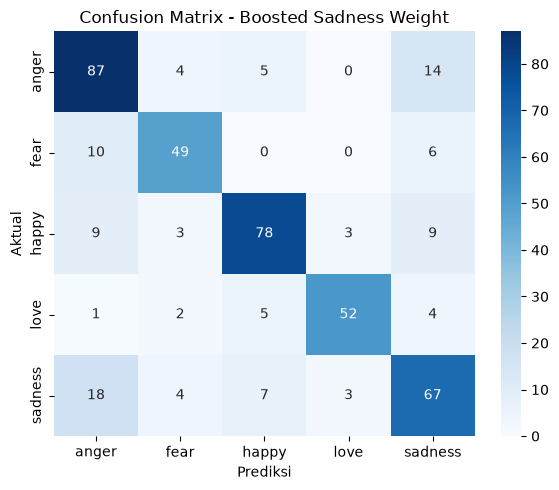

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds_output = trainer.predict(valid_dataset)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = valid_df["label_id"].tolist()

print("=== Classification Report (boosted sadness) ===")
print(classification_report(y_true, y_pred, target_names=label_list, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_list, yticklabels=label_list)
plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.title("Confusion Matrix - Boosted Sadness Weight")
plt.tight_layout()
plt.savefig("confusion_matrix_v3.png", dpi=150)
plt.show()

In [ ]:
trainer.save_model("./emotion_model_final")
tokenizer.save_pretrained("./emotion_model_final")
print("Model final tersimpan di ./emotion_model_final")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.03s/it]

Model final tersimpan di ./emotion_model_final


## 6. Bangun `app.py` — UI (CSS dipoles)

In [ ]:
%%writefile app.py
from fpdf import FPDF
import random
import re
import time, faiss, numpy as np, pickle, os
import torch.nn.functional as F
import torch
from datetime import datetime
import streamlit as st
from streamlit.components.v1 import html as components_html
from google import genai as google_genai
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from groq import Groq


st.set_page_config(page_title="Ruang Aman - Konseling Hukum UU TPKS",
                   page_icon="\U0001f49b", layout="wide",
                   initial_sidebar_state="expanded")

@st.cache_resource
def load_embed(): return SentenceTransformer("all-MiniLM-L6-v2")
@st.cache_resource
def load_store():
    return faiss.read_index("faiss_index.index"), pickle.load(open("chunks.pkl","rb"))
embed_model = load_embed()
index, chunks = load_store()

@st.cache_resource
def load_emotion_model():
    tok = AutoTokenizer.from_pretrained("./emotion_model_final")
    mdl = AutoModelForSequenceClassification.from_pretrained("./emotion_model_final")
    mdl.eval()
    return tok, mdl

emotion_tokenizer, emotion_model = load_emotion_model()

def detect_emotion(text: str) -> dict:
    inputs = emotion_tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
    with torch.no_grad():
        probs = F.softmax(emotion_model(**inputs).logits, dim=-1)[0]
    id2label_local = emotion_model.config.id2label
    scores = {id2label_local[i]: float(probs[i]) for i in range(len(probs))}
    dominant = max(scores, key=scores.get)
    return {"label_dominan": dominant, "confidence": scores[dominant], "semua_skor": scores}

DISTRESS_MAP = {
    "sadness": "tinggi",
    "fear": "tinggi",
    "anger": "sedang",
    "happy": "rendah",
    "love": "rendah",
}

def get_support_flag(text: str, threshold: float = 0.5, sadness_safety_threshold: float = 0.30) -> dict:
    r = detect_emotion(text)
    dominant = r["label_dominan"]
    level = DISTRESS_MAP.get(dominant, "rendah")
    if r["confidence"] < threshold:
        level = "rendah"
    sadness_score = r["semua_skor"].get("sadness", 0)
    if sadness_score >= sadness_safety_threshold:
        level = "tinggi"
    return {
        "emosi": dominant,
        "confidence": r["confidence"],
        "sadness_score": sadness_score,
        "distress_level": level,
        "perlu_rujukan": level == "tinggi",
    }
def generate_ai_support_label(api_key, emotion: str, user_text: str) -> str:
    if not api_key:
        return "Siap membantu dan mendengarkan ceritamu."
        
    # Arahan spesifik berdasarkan emosi yang terdeteksi
    instruction_map = {
        "sadness": "berikan 1 kalimat penguat yang sangat lembut, tunjukkan empati mendalam dan bahwa kamu ada untuknya.",
        "fear": "berikan 1 kalimat yang menenangkan kekhawatirannya, berikan kepastian bahwa dia aman bercerita di sini.",
        "anger": "berikan 1 kalimat validasi yang adem untuk menurunkan tensi emosinya tanpa menghakimi kekesalannya.",
        "happy": "berikan 1 kalimat ikut senang, antusias, dan mengapresiasi kabar baik atau energi positifnya.",
        "love": "berikan 1 kalimat apresiasi yang hangat atas kasih sayang atau cerita indahnya."
    }
    
    context_instruction = instruction_map.get(emotion, "berikan 1 kalimat respons yang hangat dan suportif.")
    
    system_prompt = (
        f"Kamu adalah konselor psikologis yang sangat empatik dan peka. "
        f"User baru saja bercerita dan sistem mendeteksi emosinya adalah '{emotion}'. "
        f"Berdasarkan potongan pesannya, {context_instruction}\n\n"
        "ATURAN MUTLAK:\n"
        "- HANYA hasilkan 1 kalimat pendek saja (maksimal 12-15 kata).\n"
        "- Gunakan bahasa Indonesia santai/kasual yang sangat natural seperti teman dekat (jangan kaku/formal).\n"
        "- DILARANG memakai tanda kutip atau kalimat pengantar seperti 'Ini kalimatnya:'."
    )
    
    try:
        client = Groq(api_key=api_key)
        # Gunakan model 8B agar super cepat (low latency)
        completion = client.chat.completions.create(
            model="llama-3.1-8b-instant", 
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Pesan user: {user_text}"}
            ],
            temperature=0.85,
            max_tokens=50
        )
        return completion.choices[0].message.content.strip()
    except Exception:
        # Fallback (cadangan) jika API Groq mendadak error/limit
        fallback = {
            "sadness": "Aku di sini mendengarkanmu. Ceritakan saja semuanya, ya.",
            "fear": "Kamu aman di sini. Tarik napas dalam-dalam, kita lalui bersama.",
            "anger": "Wajar kok kalau kamu kesal. Yuk, rehat sejenak dan tenangin pikiran.",
            "happy": "Ikut senang mendengarnya! Cerita seru apa lagi nih?",
            "love": "Terima kasih ya sudah berbagi energi positif. Kamu berharga!"
        }
        return fallback.get(emotion, "Siap membantu")


SUPPORT_MESSAGES = {
    "sadness": [
        "\U0001f90d Apa pun yang kamu rasakan sekarang itu valid. Kamu gak sendirian di sini.",
        "\U0001f90d Terima kasih udah mau cerita. Pelan-pelan aja, gak perlu buru-buru.",
        "\U0001f90d Kamu udah berani sejauh ini dengan cerita di sini. Itu bukan hal kecil.",
    ],
    "fear": [
        "\U0001fac2 Kamu aman untuk cerita di sini, dengan kecepatanmu sendiri.",
        "\U0001fac2 Gak apa-apa kalau masih takut. Kamu boleh berhenti kapan pun kamu perlu.",
        "\U0001fac2 Perasaan itu wajar. Kita jalan pelan-pelan aja, sesuai kesiapanmu.",
    ],
}

def get_support_banner(emotion_label: str):
    pool = SUPPORT_MESSAGES.get(emotion_label)
    return random.choice(pool) if pool else None
# ===================== TEMA — sesuai referensi gambar =====================
T = dict(
    navy="#0E1B48", mauve="#C18DB4", blush="#E2CAD8", skyblue="#87A7D0",
    slate="#27425D", deep="#0E1F2F",
    sidebar_top="#FDE8D3", sidebar_bottom="#F5D7DB", active="#F1916D",
    bot_bg="#F0C987", bot_border="#F59E51", bot_text="#3B153A",
    user_bg="#0E1B48", user_border="#87A7D0", user_text="#FFFFFF",
    header_title="#F0C987", header_sub="#E6E6E6",
    appbg="linear-gradient(135deg, rgba(14,27,72,0.30) 0%, rgba(193,141,180,0.30) 25%, rgba(226,202,216,0.30) 50%, rgba(135,167,208,0.30) 75%, rgba(39,66,93,0.30) 100%), #0E1F2F",
)

# Logo pakai SVG (bentuk hands+heart sesuai referensi).
LOGO_SVG = """<svg viewBox="0 0 24 24" fill="none" xmlns="http://www.w3.org/2000/svg">
    <path d="M12 8.6c-1-1.7-2.7-2.6-4.4-2.1C5.6 7 4.6 8.9 5.2 10.7c.6 2 3 4.1 6.8 6.9 3.8-2.8 6.2-4.9 6.8-6.9.6-1.8-.4-3.7-2.4-4.2-1.7-.5-3.4.4-4.4 2.1Z"
          stroke="currentColor" stroke-width="1.6" stroke-linejoin="round"/>
    <path d="M3.5 15c-.6 1.6-.2 3 1 3.9M20.5 15c.6 1.6.2 3-1 3.9"
          stroke="currentColor" stroke-width="1.6" stroke-linecap="round"/>
</svg>"""


def inject_css(t):
    st.markdown(f"""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@500;600;700;800&family=Inter:wght@400;450;500;600&display=swap');

    .stApp {{
        background:{t['appbg']};
        background-attachment:fixed;
        background-size:200% 200%;
    }}
    html, body, [class*="css"], .stMarkdown, p, span, label, div {{ font-family:'Inter',sans-serif; }}
    h1,h2,h3, .hero-title, .brand h1 {{ font-family:'Plus Jakarta Sans',sans-serif; }}
    #MainMenu, footer {{ visibility:hidden; }}
    header[data-testid="stHeader"] {{ background:transparent; }}
    [data-testid="stSidebarCollapsedControl"], [data-testid="stSidebarCollapseButton"],
    [data-testid="collapsedControl"] {{ visibility:visible !important; }}
    [data-testid="stSidebarCollapsedControl"] svg, [data-testid="stSidebarCollapseButton"] svg,
    [data-testid="collapsedControl"] svg {{ fill:{t['navy']} !important; color:{t['navy']} !important; }}
    .block-container {{ max-width:860px; padding-top:1.4rem; }}

    .glass-panel {{
        background: rgba(255,255,255,0.14);
        backdrop-filter: blur(10px);
        -webkit-backdrop-filter: blur(10px);
        border: 1px solid rgba(255,255,255,0.25);
        border-radius: 24px;
        padding: 18px 20px 8px;
        margin-bottom: 14px;
        box-shadow: 0 8px 32px rgba(14,27,72,.18);
    }}

    /* ============ HEADER UTAMA — PERMANEN: Logo / Ruang Aman / Sub-judul ============ */
    .main-chat-header {{ text-align:center; margin:4px 0 18px; }}
    .main-chat-header .logo-badge {{
        width:56px; height:56px; margin:0 auto 12px; border-radius:16px;
        background:linear-gradient(135deg, {t['mauve']} 0%, {t['skyblue']} 100%);
        color:#fff; display:flex; align-items:center; justify-content:center;
        box-shadow:0 10px 24px rgba(193,141,180,.4);
    }}
    .main-chat-header .logo-badge svg {{ width:28px; height:28px; }}
    .main-chat-header .title {{
        font-family:'Plus Jakarta Sans', sans-serif;
        font-weight:800;
        font-size:30px;
        color:{t['header_title']};
        letter-spacing:-0.3px;
        margin-bottom:4px;
    }}
    .main-chat-header .subtitle {{
        font-family:'Inter', sans-serif;
        font-weight:400;
        font-size:15px;
        color:{t['header_sub']};
    }}
    
    /* ============ KARTU 6 FITUR — scoped ke container(key="fitur_grid") ============ */
    .st-key-fitur_grid [data-testid="column"] {{
        display: flex;
    }}
    .st-key-fitur_grid div.stButton {{
        width: 100%;
    }}
    .st-key-fitur_grid div.stButton > button {{
        height: 92px !important;
        display: flex !important;
        flex-direction: column !important;
        justify-content: center !important;
        gap: 4px;
    }}
    .st-key-fitur_grid div.stButton > button p {{
        color:#FFFFFF !important;
        font-weight:700 !important;
        font-size: 13.5px !important;
        line-height: 1.35 !important;
    }}
    .st-key-f0 button, .st-key-f2 button, .st-key-f4 button {{
        background:linear-gradient(135deg, {t['navy']} 0%, {t['slate']} 100%) !important;
    }}
    .st-key-f1 button, .st-key-f3 button, .st-key-f5 button {{
        background:linear-gradient(135deg, {t['navy']} 0%, {t['mauve']} 100%) !important;
    }}
   
    /* ============ SAFETY NET —  ============ */
    div[data-testid="stVerticalBlockBorderWrapper"],
    div[data-testid="stVerticalBlock"] > div[style*="background"],
    .stAlert, div[data-testid="stNotification"],
    div[data-testid="stExpander"], div[data-testid="stExpanderDetails"] {{
        background: rgba(14,27,72,0.55) !important;
        backdrop-filter: blur(6px);
        color: #FFFFFF !important;
        border-color: rgba(255,255,255,0.15) !important;
    }}
    div[data-testid="stExpander"] p, div[data-testid="stExpander"] span,
    div[data-testid="stExpander"] li, div[data-testid="stExpander"] a {{
        color: #FFFFFF !important;
    }}
    /* di dalam sidebar tetap ikutin tema krem, override balik supaya nggak ikut jadi gelap */
    section[data-testid="stSidebar"] div[data-testid="stExpander"],
    section[data-testid="stSidebar"] div[data-testid="stExpanderDetails"] {{
        background: rgba(255,255,255,0.25) !important;
        color: {t['navy']} !important;
    }}
    section[data-testid="stSidebar"] div[data-testid="stExpander"] p,
    section[data-testid="stSidebar"] div[data-testid="stExpander"] span,
    section[data-testid="stSidebar"] div[data-testid="stExpander"] li,
    section[data-testid="stSidebar"] div[data-testid="stExpander"] a {{
        color: {t['navy']} !important;
    }}

    /* ============ CHAT BUBBLE — user di kanan, bot di kiri, seperti chat asli ============ */
    [data-testid="stChatMessage"] {{ background:transparent; border:none; padding:4px 0; gap:12px; }}
    [data-testid="stChatMessageContent"] {{
        max-width: 680px;
        border-radius:18px; padding:13px 18px;
        box-shadow:0 3px 10px rgba(14,27,72,.12);
    }}
    [data-testid="stChatMessageContent"] p, [data-testid="stChatMessageContent"] li {{
        font-size:14.8px; line-height:1.7;
    }}
    
    /* ============ AVATAR — target struktural, tidak bergantung nama testid ============ */
    [data-testid="stChatMessage"] > div:first-child,
    [data-testid="stChatMessage"] [data-testid*="Avatar" i],
    [data-testid="stChatMessage"] [data-testid*="avatar" i] {{
        background: linear-gradient(135deg, {t['mauve']} 0%, {t['active']} 100%) !important;
        border-radius: 12px !important;
        overflow: hidden;
    }}
    [data-testid="stChatMessage"] > div:first-child *,
    [data-testid="stChatMessage"] [data-testid*="Avatar" i] *,
    [data-testid="stChatMessage"] [data-testid*="avatar" i] * {{
        background: transparent !important;
    }}

    /* USER = ganjil (pesan pertama): avatar & bubble ke KANAN */
    div[data-testid="stChatMessage"]:nth-of-type(odd) {{
        flex-direction: row-reverse;
        justify-content: flex-start;
    }}
    div[data-testid="stChatMessage"]:nth-of-type(odd) [data-testid="stChatMessageContent"] {{
        background:{t['user_bg']}; border:1.5px solid {t['user_border']};
        margin-left: auto;
    }}
    div[data-testid="stChatMessage"]:nth-of-type(odd) [data-testid="stChatMessageContent"] p,
    div[data-testid="stChatMessage"]:nth-of-type(odd) [data-testid="stChatMessageContent"] li,
    div[data-testid="stChatMessage"]:nth-of-type(odd) [data-testid="stChatMessageContent"] strong {{
        color:{t['user_text']} !important;
    }}

    /* BOT = genap: avatar & bubble tetap di KIRI */
    div[data-testid="stChatMessage"]:nth-of-type(even) {{
        flex-direction: row;
        justify-content: flex-start;
    }}
    div[data-testid="stChatMessage"]:nth-of-type(even) [data-testid="stChatMessageContent"] {{
        background:{t['bot_bg']}; border:1.5px solid {t['bot_border']};
        margin-right: auto;
    }}
    div[data-testid="stChatMessage"]:nth-of-type(even) [data-testid="stChatMessageContent"] p,
    div[data-testid="stChatMessage"]:nth-of-type(even) [data-testid="stChatMessageContent"] li,
    div[data-testid="stChatMessage"]:nth-of-type(even) [data-testid="stChatMessageContent"] strong {{
        color:{t['bot_text']} !important;
    }}

    /* fallback presisi lewat aria-label avatar, kalau browser dukung :has() */
    div[data-testid="stChatMessage"]:has([aria-label*="user" i]) {{
        flex-direction: row-reverse !important; justify-content: flex-start !important;
    }}
    div[data-testid="stChatMessage"]:has([aria-label*="user" i]) [data-testid="stChatMessageContent"] {{
        background:{t['user_bg']} !important; border:1.5px solid {t['user_border']} !important;
        margin-left: auto !important;
    }}
    div[data-testid="stChatMessage"]:has([aria-label*="user" i]) [data-testid="stChatMessageContent"] p,
    div[data-testid="stChatMessage"]:has([aria-label*="user" i]) [data-testid="stChatMessageContent"] li {{
        color:{t['user_text']} !important;
    }}
    div[data-testid="stChatMessage"]:has([aria-label*="assistant" i]) {{
        flex-direction: row !important; justify-content: flex-start !important;
    }}
    div[data-testid="stChatMessage"]:has([aria-label*="assistant" i]) [data-testid="stChatMessageContent"] {{
        background:{t['bot_bg']} !important; border:1.5px solid {t['bot_border']} !important;
        margin-right: auto !important;
    }}
    div[data-testid="stChatMessage"]:has([aria-label*="assistant" i]) [data-testid="stChatMessageContent"] p,
    div[data-testid="stChatMessage"]:has([aria-label*="assistant" i]) [data-testid="stChatMessageContent"] li {{
        color:{t['bot_text']} !important;
    }}

    /* ============ SIDEBAR — gradient krem ============ */
    section[data-testid="stSidebar"] {{
        background:linear-gradient(180deg, {t['sidebar_top']} 0%, {t['sidebar_bottom']} 100%);
        border-right:1px solid rgba(14,27,72,.08);
    }}
    section[data-testid="stSidebar"] * {{ color:{t['navy']}; }}

    .sidebar-logo-wrap {{ text-align:center; margin-top:6px; margin-bottom:10px; }}
    .sidebar-logo {{
        width:56px; height:56px; margin:0 auto; border-radius:50%;
        background:linear-gradient(135deg, {t['mauve']} 0%, {t['blush']} 100%); color:{t['navy']};
        display:flex; align-items:center; justify-content:center;
        box-shadow:0 6px 16px rgba(193,141,180,.4);
    }}
    .sidebar-logo svg {{ width:28px; height:28px; }}
    .sidebar-brand-title {{
        text-align:center; font-weight:700; font-size:21px; color:{t['navy']};
        margin:10px 0 2px; line-height:1.15;
    }}
    .sidebar-brand-sub {{
        text-align:center; font-style:italic; font-size:12px; color:{t['navy']};
        margin-bottom:14px; opacity:.85;
    }}
    
    section[data-testid="stSidebar"] div.stButton > button {{
        background:{t['navy']}; color:#fff !important; border:none; font-weight:600;
        border-radius:14px; padding:12px 14px; box-shadow:0 6px 14px rgba(14,27,72,.2);
    }}
    section[data-testid="stSidebar"] div.stButton > button:hover {{ filter:brightness(1.15); }}
    section[data-testid="stSidebar"] div.stButton > button p {{ color:#fff !important; }}

    /* ============ MENU ACTIVE / INACTIVE — pembeda jelas ============ */
    section[data-testid="stSidebar"] button[kind="secondary"],
    section[data-testid="stSidebar"] [data-testid="stBaseButton-secondary"] {{
        background:transparent !important; color:{t['navy']} !important; font-weight:700 !important;
        border:1.5px solid transparent !important; box-shadow:none !important; text-align:left !important;
        border-radius:14px !important;
    }}
    section[data-testid="stSidebar"] button[kind="secondary"] p,
    section[data-testid="stSidebar"] [data-testid="stBaseButton-secondary"] p {{
        color:{t['navy']} !important; font-weight:700 !important;
    }}
    section[data-testid="stSidebar"] button[kind="secondary"]:hover,
    section[data-testid="stSidebar"] [data-testid="stBaseButton-secondary"]:hover {{
        background:rgba(241,145,109,.16) !important; border-color:rgba(241,145,109,.4) !important;
    }}

    section[data-testid="stSidebar"] button[kind="primary"],
    section[data-testid="stSidebar"] [data-testid="stBaseButton-primary"] {{
        background:{t['active']} !important; color:#FFFFFF !important; font-weight:800 !important;
        border:3.5px solid {t['active']} !important; border-radius:14px !important; text-align:left !important;
        box-shadow:0 8px 18px rgba(241,145,109,.45) !important;
    }}
    section[data-testid="stSidebar"] button[kind="primary"] p,
    section[data-testid="stSidebar"] button[data-testid="stBaseButton-primary"] p {{
        color: #FFFFFF !important;
        font-weight: 800 !important;
    }}

    section[data-testid="stSidebar"] div[data-testid="stButton"]:nth-of-type(1) button {{
        background:{t['navy']} !important; color:#fff !important; box-shadow:0 6px 14px rgba(14,27,72,.2) !important;
        text-align:center !important;
    }}
    section[data-testid="stSidebar"] div[data-testid="stButton"]:nth-of-type(1) button p {{ color:#fff !important; }}

    section[data-testid="stSidebar"] .streamlit-expanderHeader {{
        font-weight:600; color:{t['navy']} !important; background:transparent !important;
    }}

    section[data-testid="stSidebar"] div[data-testid="stDownloadButton"] button {{
        background:{t['navy']} !important; color:#fff !important; border:none !important;
        font-weight:600 !important; border-radius:14px !important; padding:12px 14px !important;
        box-shadow:0 6px 14px rgba(14,27,72,.2) !important;
    }}
    section[data-testid="stSidebar"] div[data-testid="stDownloadButton"] button p {{ color:#fff !important; }}

    /* ============ EXPANDER SIDEBAR (Pengaturan / Bantuan Langsung) — hilangkan bg putih bawaan ============ */
    section[data-testid="stSidebar"] [data-testid="stExpander"] {{
        background: rgba(255, 255, 255, 0.2) !important;
        border: 1px solid rgba(14, 27, 72, 0.12) !important;
        border-radius: 16px !important;
        overflow: hidden !important;
    }}
    section[data-testid="stSidebar"] [data-testid="stExpanderDetails"] {{
        padding: 12px 14px 22px 14px !important;
        background: transparent !important;
    }}
    }}
    .emergency-card {{
        display: block;
        color: {t['navy']};
        text-align: left;
    }}
    .emergency-title {{
        font-size: 16px;
        font-weight: 800;
        letter-spacing: -0.3px;
        color: {t['navy']};
        line-height: 1.2;
    }}
    .emergency-subtitle {{
        font-size: 12px;
        font-weight: 600;
        opacity: 0.8;
        margin-bottom: 10px;
    }}
    .emergency-desc {{
        font-size: 12px;
        line-height: 1.5;
        margin-bottom: 12px;
        opacity: 0.85;
    }}
    .emergency-btn {{
        display: block !important;
        text-align: center !important;
        background: #25D366 !important; /* Warna hijau khas WhatsApp agar intuitif */
        color: #FFFFFF !important;
        text-decoration: none !important;
        font-weight: 700 !important;
        font-size: 12.5px !important;
        padding: 10px 12px !important;
        border-radius: 10px !important;
        box-shadow: 0 4px 12px rgba(37, 211, 102, 0.2) !important;
        transition: all 0.2s ease !important;
    }}
    .emergency-btn:hover {{
        background: #128C7E !important;
        box-shadow: 0 6px 16px rgba(37, 211, 102, 0.35) !important;
    }}
    section[data-testid="stSidebar"] [data-testid="stExpander"] summary {{
        background: transparent !important;
    }}
    section[data-testid="stSidebar"] [data-testid="stExpander"] summary:hover {{
        background: rgba(241,145,109,.12) !important;
    }}
    section[data-testid="stSidebar"] [data-testid="stExpanderDetails"] {{
        background: transparent !important;
    }}
    section[data-testid="stSidebar"] [data-testid="stExpander"] p,
    section[data-testid="stSidebar"] [data-testid="stExpander"] a,
    section[data-testid="stSidebar"] [data-testid="stExpander"] li {{
        color:{t['navy']} !important;
    }}

    /* ============ KARTU INFORMASI PENGATURAN (KELUAR CEPAT) ============ */
    .settings-info-card {{
        background: rgba(216, 52, 42, 0.08) !important; /* Warna merah transparan tipis */
        border-left: 3.5px solid #D8342A !important; /* Aksen garis merah tegas di kiri */
        border-radius: 10px !important;
        padding: 10px 12px !important;
        margin-bottom: 16px !important;
        text-align: left !important;
    }}
    .settings-info-title {{
        font-size: 13.5px !important;
        font-weight: 700 !important;
        color: {t['navy']} !important;
        margin-bottom: 4px !important;
    }}
    .settings-info-desc {{
        font-size: 11.5px !important;
        line-height: 1.5 !important;
        color: {t['navy']} !important;
        opacity: 0.85 !important;
    }}
    
    /* ============ MERAPIKAN WIDGET RADIO BUTTON SIDEBAR ============ */
    /* Merapikan label utama "Ukuran teks" */
    section[data-testid="stSidebar"] div[data-testid="stRadio"] label p {{
        font-size: 13.5px !important;
        font-weight: 700 !important;
        color: {t['navy']} !important;
        margin-bottom: 8px !important;
    }}
    
    /* Memberikan jarak renggang yang proporsional antar opsi pilihan */
    section[data-testid="stSidebar"] div[data-testid="stRadio"] [data-testid="stWidgetLabel"] + div {{
        gap: 16px !important;
    }}
    
    /* Mengatur teks opsi (Kecil, Sedang, Besar) agar lebih tegas */
    section[data-testid="stSidebar"] div[data-testid="stRadio"] div[data-testid="stMarkdownContainer"] p {{
        font-size: 13px !important;
        font-weight: 500 !important;
        color: {t['navy']} !important;
    }}

    /* ============ SUGGESTION CHIPS — pakai container(key=) yang beneran nge-wrap ============ */
    .st-key-chip_row div.stButton > button {{
        background:rgba(255,255,255,0.55) !important; color:{t['navy']} !important;
        border:1.5px solid {t['skyblue']} !important; border-radius:999px !important;
        padding:6px 16px !important; font-size:13px !important; font-weight:600 !important;
        box-shadow:none !important; min-height:auto !important;
    }}
    .st-key-chip_row div.stButton > button p {{ color:{t['navy']} !important; font-size:13px !important; }}
    .st-key-chip_row div.stButton > button:hover {{
        background:{t['mauve']} !important; color:#fff !important; border-color:{t['mauve']} !important;
    }}
    .st-key-chip_row div.stButton > button:hover p {{ color:#fff !important; }}

   /* ============ INPUT CHAT - OBLITERASI TOTAL KOTAK & HOVER MERAH ============ */
    [data-testid="stChatInput"] {{
        background: rgba(255, 255, 255, 0.96) !important;
        border: 1.5px solid {t['skyblue']} !important;
        border-radius: 40px !important;
        box-shadow: 0 4px 14px rgba(14, 27, 72, 0.15) !important;
    }}
    
    [data-testid="stChatInput"] * {{
        background-color: transparent !important;
    }}
    
    [data-testid="stBottom"] {{
        background: {t['deep']} !important;
    }}
    
    div[data-testid="stBottomBlockContainer"] {{
        max-width: 100% !important;
        padding-left: 30px !important;
        padding-right: 30px !important;
        background: {t['deep']} !important;
    }}
    
    div[data-testid="stBottom"] > div {{
        background: transparent !important;
    }}
    
    [data-testid="stChatInput"] textarea {{
        color: {t['navy']} !important;
        -webkit-text-fill-color: {t['navy']} !important;
        caret-color: {t['navy']} !important;
        font-size: 15px !important;
    }}
    
    [data-testid="stChatInput"] textarea::placeholder {{
        color: #9aa3b5 !important;
        -webkit-text-fill-color: #9aa3b5 !important;
        opacity: 1 !important;
    }}
    
    [data-testid="stChatInput"]:focus-within {{
        border-color: {t['active']} !important;
        box-shadow: 0 0 0 3px rgba(241, 145, 109, 0.2) !important;
    }}
    
    /* 🔥 TOMBOL INDUK: Kunci bentuk lingkaran sempurna & ukuran presisi 🔥 */
    [data-testid="stChatInput"] button,
    [data-testid="stChatInputSubmitButton"] {{
        background-color: {t['mauve']} !important;
        border-radius: 50% !important;
        border: none !important;
        outline: none !important;
        box-shadow: none !important;
        padding: 6px !important;
        width: 32px !important;
        height: 32px !important;
        display: flex !important;
        align-items: center !important;
        justify-content: center !important;
        transition: all 0.2s ease !important;
    }}
    
    /* 🔥 KUNCI UTAMA (HOVER & FOCUS PROTECTION): Mencegah tombol berubah jadi blok merah 🔥 */
    [data-testid="stChatInput"] button:hover,
    [data-testid="stChatInputSubmitButton"]:hover,
    [data-testid="stChatInput"] button:active,
    [data-testid="stChatInput"] button:focus,
    [data-testid="stChatInput"] button:focus-visible {{
        background-color: {t['mauve']} !important; /* Paksa tetap berwarna mauve */
        filter: brightness(0.88) !important; /* Memberikan efek hover gelap yang elegan & smooth, BUKAN merah */
        border: none !important;
        outline: none !important;
        box-shadow: none !important;
    }}
    
    /* 🔥 ANTI-KOTAK PUTIH: Hancurkan paksa sisa garis kotak di elemen dalam saat hover/focus 🔥 */
    [data-testid="stChatInput"] button *,
    [data-testid="stChatInputSubmitButton"] *,
    [data-testid="stChatInput"] button div,
    [data-testid="stChatInput"] button span {{
        border: none !important;
        border-width: 0px !important;
        outline: none !important;
        outline-style: none !important;
        outline-width: 0px !important;
        box-shadow: none !important;
        background: transparent !important;
        background-color: transparent !important;
    }}
    
    /* Singkirkan sisa rect grafis pembungkus bawaan SVG jika ada */
    [data-testid="stChatInput"] button svg rect,
    [data-testid="stChatInputSubmitButton"] svg rect {{
        display: none !important;
        stroke: transparent !important;
        fill: transparent !important;
    }}
    
    /* 🔥 PROTEKSI PANAH UTAMA: Memastikan ikon panah tetap menyala putih bersih & proporsional 🔥 */
    [data-testid="stChatInput"] button svg,
    [data-testid="stChatInputSubmitButton"] svg {{
        display: inline-block !important;
        color: #FFFFFF !important;
        stroke: #FFFFFF !important;
        stroke-width: 2.5px !important;
        fill: none !important;
        width: 18px !important;
        height: 18px !important;
        border: none !important;
        outline: none !important;
    }}

    .disclaimer {{ font-size:11px; line-height:1.55; color:{t['slate']} !important; margin-top:14px;
        border-top:1px solid rgba(14,27,72,.12); padding-top:12px; }}
    .key-ok {{ font-size:12px; color:{t['active']}; font-weight:700; padding:4px 0; }}
    .support-banner {{
        background: rgba(255,255,255,0.6);
        border-left: 4px solid {t['active']};
        border-radius: 12px;
        padding: 12px 16px;
        margin: 6px 0 14px 0;
        font-size: 13.5px;
        color: {t['navy']};
        line-height: 1.6;
    }}
    </style>""", unsafe_allow_html=True)

FITUR = [
    ("\U0001f91d Konseling Kasus", "Cerita situasimu, dapat arahan empatik",
     "Saya mengalami situasi yang mungkin termasuk kekerasan seksual. Bisa bantu saya memahami apa yang terjadi?"),
    ("\U0001f4d1 Jenis & Pasal", "Jenis TPKS dan dasar hukumnya",
     "Apa saja jenis tindak pidana kekerasan seksual dalam UU TPKS?"),
    ("\u2696\ufe0f Ancaman Pidana", "Sanksi penjara & denda",
     "Berapa ancaman pidana untuk pelecehan seksual fisik dan eksploitasi seksual?"),
    ("\U0001f6e1\ufe0f Hak Korban", "Restitusi & pemulihan",
     "Apa saja hak korban dan bagaimana mekanisme restitusi menurut UU TPKS?"),
    ("\U0001f4cb Alur Melapor", "Langkah lapor & pembuktian",
     "Bagaimana cara melapor kasus kekerasan seksual dan alat bukti apa yang diakui?"),
    ("\U0001f4de Bantuan Darurat", "Kontak lembaga layanan",
     "Saya butuh nomor dan kontak lembaga bantuan untuk korban kekerasan seksual."),
]

MENU_ITEMS = [
    ("konseling", "\U0001f91d", "Konseling"),
    ("pasal", "\u2696\ufe0f", "Telusur Pasal"),
    ("lapor", "\U0001f4cb", "Panduan Lapor"),
]
MENU_LABELS = {"konseling": "Konseling", "pasal": "Telusur Pasal", "lapor": "Panduan Lapor"}

THRESHOLD = 0.5
def retrieve(query, k=4, th=THRESHOLD):
    m = re.search(r"pasal\s+(\d{1,3})\b", query, re.IGNORECASE)
    exact_ctx = []
    if m:
        num = m.group(1)
        pat = re.compile(rf"(?:^|\]\s*)Pasal\s+{num}\b")
        exact_ctx = [c for c in chunks if pat.search(c)]

    q = embed_model.encode([query]); faiss.normalize_L2(q)
    D, I = index.search(np.array(q).astype("float32"), k)
    sem_ctx = [chunks[i] for i, s in zip(I[0], D[0]) if s >= th]

    ctx = exact_ctx + [c for c in sem_ctx if c not in exact_ctx]
    sim = 1.0 if exact_ctx else float(D[0][0])
    return ctx, sim

BASE = """Kamu adalah "Pasal", asisten hukum berbahasa Indonesia yang HANYA membahas
UU No. 12 Tahun 2022 tentang Tindak Pidana Kekerasan Seksual (UU TPKS).

PRINSIP WAJIB:
BASE = """Kamu adalah "Pasal", asisten hukum berbahasa Indonesia yang HANYA membahas
UU No. 12 Tahun 2022 tentang Tindak Pidana Kekerasan Seksual (UU TPKS).

PRINSIP WAJIB:
- SEBELUM menjawab, cek dulu: apakah pertanyaan user ADA HUBUNGANNYA dengan kekerasan
  seksual, TPKS, atau isi UU ini? Kalau SAMA SEKALI TIDAK NYAMBUNG (tips skripsi, resep
  masakan, coding, dll), JANGAN dipaksa dikait-kaitkan ke pasal apapun. Jawab singkat
  bahwa kamu cuma fokus bahas UU TPKS.
- Jawab HANYA dari materi pasal yang tersedia. Dilarang mengarang pasal/angka. Kalau
  jawabannya nggak ada, bilang terus terang lalu arahkan ke bantuan resmi.
- Sebut nomor pasal HANYA kalau ISINYA SPESIFIK ke situasi (jenis kekerasan tertentu,
  hak korban tertentu, sanksi tertentu). Pasal definisi umum/pembukaan BUKAN dasar kuat —
  jangan dipaksa disebut. Kalau nggak ada yang pas, jangan sebut pasal sama sekali.
- DILARANG MUTLAK menyebut kata "konteks", "kutipan", atau "yang diberikan/disediakan/
  tersedia" dalam bentuk apapun. User nggak tahu ada proses retrieval di baliknya. Kalau
  pasal nggak ada yang pas, LEWATI SAJA tanpa billing "tidak ada info" — fokus ke dukungan/
  panduannya aja.
- Sapaan WAJIB konsisten "kamu" dari awal sampai akhir. JANGAN PERNAH pakai "Anda".
- HINDARI kata "saya"/"aku" sama sekali saat chatbot merujuk ke dirinya sendiri. Tulis
  ulang kalimatnya biar nggak butuh kata ganti orang pertama.
- DILARANG memulai kalimat pertama jawaban dengan kata "Kamu"/"Anda", dan DILARANG kalimat
  pertama berupa rangkuman/label ulang atas cerita user dalam bentuk apapun (co: "Percakapan
  yang kamu alami itu terdengar tidak nyaman..."). Langsung ke insight/reaksi/info baru.
  Di paragraf manapun, maksimal 1 kalimat yang diawali "Kamu" — kalimat lain pakai struktur
  beda (kata kerja, situasi, atau klausa "Kalau...", "Karena...").
- DILARANG mengulang parafrase situasi user yang SUDAH disebut di giliran sebelumnya.
  Anggap itu udah established, lanjut ke hal baru.
- MAKSIMAL 1 tanda tanya per jawaban. Kalau nggak ada yang perlu ditanya, tutup dengan
  pernyataan/langkah konkret tanpa tanda tanya.
- Tulis dengan bahasa manusia yang mengalir, natural, dan BERVARIASI tiap respons (struktur/
  opening/closing, bukan cuma variasi kata). DILARANG KERAS kalimat pembuka klise: "Maaf
  mendengar...", "Terima kasih sudah berbagi...".
- Jangan menjejalkan kontak SAPA 129 di setiap jawaban; sebut hanya bila relevan.
- Kalimat pertama jawaban HARUS langsung berisi salah satu dari: (a) informasi/insight baru
  yang belum disebut user, (b) pertanyaan balik jika benar-benar perlu, atau (c) langkah/opsi
  konkret. DILARANG kalimat pertama berupa PARAFRASE situasi user dalam bentuk apapun, termasuk
  yang berbunyi "Kalau [situasi]...", "Posisi/Keadaan/Situasi [X] itu...", "Kamu sudah/sedang...".
  Contoh BENAR: "Menolak permintaan itu adalah hakmu, dan penolakan itu sendiri sudah cukup —
  nggak perlu alasan tambahan." Contoh SALAH: "Kalau pacarmu meminta hal itu, itu bisa membuatmu
  tidak nyaman." (ini parafrase, dilarang)
- WAJIB menyelipkan emoji/emoticon yang relevan, hangat, dan menenangkan di setiap respons (misalnya: 🫂, 💛, 🛡️, ✨) di dalam bubble chat agar terasa suportif dan ramah.
"""
PROMPTS = {
"konseling": BASE + '''

PERAN SEKARANG: KONSELOR (bukan customer service, bukan legal-bot).
Baca cerita orangnya dulu, reaksi dengan cara yang nunjukin kamu beneran nangkep detailnya
(sebut ulang elemen spesifik dari ceritanya dengan kata-katamu sendiri, bukan parafrase kaku).
Validasi perasaannya tanpa menggurui. Kalau ada pasal yang BENAR-BENAR pas dengan situasinya,
selipkan natural di tengah kalimat (bukan sebagai poin terpisah/dokumentatif). Kalau nggak ada
pasal yang pas, itu OK — nggak usah dipaksa nyebut pasal sama sekali di respons ini.
Tutup dengan sesuatu yang konkret: satu langkah kecil yang relevan buat situasi dia, ATAU
ajakan buat cerita lebih lanjut yang terasa personal (bukan template).
Nada: seperti teman yang paham hukum, bukan seperti membacakan pasal. Maksimal 4 paragraf pendek,
variasikan panjang & struktur kalimat supaya nggak kerasa template.

JAGA KESELAMATAN EMOSIONAL — INI PRIORITAS DI ATAS INFORMASI HUKUM:
- Jangan pernah membuat user merasa lebih bersalah, lebih takut, atau lebih terpojok dari
  sebelum dia curhat. Kalau ragu antara jawaban yang "lengkap secara hukum" vs "aman secara
  emosional", pilih yang aman secara emosional.
- Jangan memaksa/mendesak user buat lapor, konfrontasi pelaku, atau ambil tindakan tertentu.
  Tawarkan opsi, bukan instruksi. Hormati kalau dia belum siap atau belum mau bertindak.
- Kalau user menunjukkan tanda distress berat (putus asa, menyalahkan diri berlebihan,
  menyebut ingin menyakiti diri), JANGAN lanjut bahas pasal/hukum dulu — fokus ke stabilisasi
  emosinya dan arahkan ke bantuan profesional/hotline dengan tenang, bukan dengan 
  
  .
- Jangan membombardir dengan banyak istilah hukum sekaligus kalau user kelihatan rapuh —
  cukup satu poin paling penting per respons, sisanya bisa nunggu giliran berikutnya.''',

"pasal": BASE + '''

PERAN SEKARANG: PENELUSUR PASAL.
Jawab lugas dan informatif seperti referensi hukum. Sebutkan pasal + isi pokoknya +
ancaman pidana (penjara/denda) bila ada. Boleh pakai poin bernomor agar rapi.
Minim basa-basi empati; langsung ke substansi hukum. Sebut nomor pasal dengan tepat.''',

"lapor": BASE + '''

PERAN SEKARANG: PEMANDU PELAPORAN.
Beri panduan PRAKTIS dan berurutan: ke mana melapor (UPTD PPA, Unit PPA Polisi),
bukti/dokumen yang perlu disiapkan, hak korban selama proses, dan apa yang terjadi
setelah lapor. Susun sebagai langkah 1-2-3 yang mudah diikuti. Rujuk pasal terkait
(mis. pelaporan, alat bukti, perlindungan). Akhiri dengan kontak resmi bila relevan.''',
}


def groq_answer(api_key, user_input, history, mode, support_info):
    ctx_list, sim = retrieve(user_input)
    context = "\n\n".join(f"[Kutipan {i+1}] {c}" for i, c in enumerate(ctx_list)) if ctx_list \
              else "(Tidak ada pasal relevan di atas ambang. Sampaikan jujur & arahkan ke bantuan resmi.)"
    system_prompt = PROMPTS[mode]

    if support_info["perlu_rujukan"]:
        system_prompt += (
            "\n\nCATATAN TAMBAHAN: User tampak sedang dalam kondisi tertekan/sedih. "
            "Jawab dengan nada empatik dan hati-hati, dan sisipkan secara halus "
            "bahwa ada layanan pendampingan seperti SAPA 129 yang bisa dihubungi "
            "kalau butuh bantuan lebih lanjut. Jangan terkesan menghakimi atau memberi diagnosis."
        )

    user_msg = f"PERTANYAAN PENGGUNA:\n{user_input}\n\nKONTEKS PASAL UU TPKS (relevansi {sim:.0%}):\n{context}"
    # ... sisanya (msgs, groq_keys, stream, dst) TETAP SAMA, gak perlu diubah
    msgs = [{"role": "system", "content": system_prompt}]
    for h in history[-6:]:
        msgs.append({"role": h["role"], "content": h["content"]})
    msgs.append({"role": "user", "content": user_msg})

    groq_keys = [k for k in [api_key, os.environ.get("GROQ_API_KEY_2", "")] if k]
    for idx, key in enumerate(groq_keys):
        try:
            client = Groq(api_key=key)
            stream = client.chat.completions.create(
                model="llama-3.3-70b-versatile", messages=msgs, temperature=0.75, max_tokens=900, stream=True)
            got_chunk = False
            for chunk in stream:
                d = chunk.choices[0].delta.content
                if d:
                    got_chunk = True
                    yield d
            if got_chunk:
                return
        except Exception as e:
            print(f"[GROQ key #{idx+1} GAGAL] {type(e).__name__}: {e}", flush=True)
            continue

    yield "\u26a0\ufe0f Groq sedang limit. Coba lagi beberapa saat lagi.\n\nKalau mendesak, hubungi **SAPA 129**."

def _pdf_sanitize(text):
    replacements = {
        "\u2014": "-", "\u2013": "-", "\u2018": "'", "\u2019": "'",
        "\u201c": '"', "\u201d": '"', "\u2026": "...",
        "═": "=", "─": "-", "\U0001f49b": "", "\U0001f464": "",
    }
    for k, v in replacements.items():
        text = text.replace(k, v)
    return text.encode("latin-1", errors="ignore").decode("latin-1")

def build_transcript_pdf():
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()

    pdf.set_font("Helvetica", "B", 14)
    pdf.set_x(pdf.l_margin)
    pdf.multi_cell(0, 8, _pdf_sanitize("RUANG AMAN - RINGKASAN PERCAKAPAN"), align="C")
    pdf.ln(2)

    pdf.set_font("Helvetica", "", 10)
    meta = [
        f"Sesi dimulai   : {st.session_state.session_started.strftime('%d %B %Y, %H:%M:%S')}",
        f"Diunduh pada   : {datetime.now().strftime('%d %B %Y, %H:%M:%S')}",
        f"Mode konseling : {MENU_LABELS.get(st.session_state.active_menu, '-')}",
        f"Jumlah pesan   : {len(st.session_state.messages)}",
    ]
    for line in meta:
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(0, 6, _pdf_sanitize(line))

    pdf.ln(3)
    pdf.set_draw_color(150, 150, 150)
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())
    pdf.ln(5)

    for m in st.session_state.messages:
        who = "USER" if m["role"] == "user" else "RUANG AMAN"
        ts = m.get("time")
        ts_str = ts.strftime("%H:%M:%S") if ts else "-"

        pdf.set_font("Helvetica", "B", 10)
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(0, 6, _pdf_sanitize(f"[{ts_str}] {who}:"))

        pdf.set_font("Helvetica", "", 10)
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(0, 6, _pdf_sanitize(m["content"]))
        pdf.ln(2)

    pdf.set_draw_color(150, 150, 150)
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())
    pdf.ln(4)

    pdf.set_font("Helvetica", "I", 8)
    for line in [
        "Dokumen ini dibuat otomatis oleh Ruang Aman.",
        "Bukan pengganti dokumen resmi kepolisian/lembaga hukum.",
        "Darurat? Hubungi SAPA 129.",
    ]:
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(0, 5, _pdf_sanitize(line))

    return bytes(pdf.output())

for k, v in [("messages", []), ("active_menu", "konseling"), ("pending", None), ("text_size", "Sedang"), ("last_emotion_result", None)]:
    if k not in st.session_state: st.session_state[k] = v
if "session_started" not in st.session_state:
    st.session_state.session_started = datetime.now()


inject_css(T)

FONT_SIZES = {
    "Kecil":  {"chat": "13px",   "input": "13px"},
    "Sedang": {"chat": "14.8px", "input": "15px"},
    "Besar":  {"chat": "18px",   "input": "18px"},
}

def inject_text_size_css(size_label):
    s = FONT_SIZES.get(size_label, FONT_SIZES["Sedang"])
    st.markdown(f"""
    <style>
    [data-testid="stChatMessageContent"] p, [data-testid="stChatMessageContent"] li {{
        font-size: {s['chat']} !important;
        line-height: 1.75 !important;
    }}
    [data-testid="stChatInput"] textarea {{
        font-size: {s['input']} !important;
    }}
    </style>
    """, unsafe_allow_html=True)

# ===================== PANIC EXIT — tombol darurat, fixed, selalu terlihat =====================
st.markdown(f"""
<style>
/* 1. MEMBUAT TOMBOL TOGGLE SIDEBAR STREAMLIT MENJADI SANGAT JELAS & ELEGAN */
[data-testid="stSidebarCollapsedControl"] {{
    background: rgba(255, 255, 255, 0.95) !important;
    border: 1.5px solid rgba(14, 27, 72, 0.2) !important;
    border-radius: 50% !important;
    top: 14px !important;
    left: 16px !important;
    width: 40px !important;
    height: 40px !important;
    display: flex !important;
    align-items: center !important;
    justify-content: center !important;
    box-shadow: 0 4px 14px rgba(0, 0, 0, 0.2) !important;
    z-index: 9999998 !important;
    transition: all 0.2s ease !important;
}}
[data-testid="stSidebarCollapsedControl"]:hover {{
    background: #FFFFFF !important;
    transform: scale(1.08);
}}
/* Mewarnai ikon panah internal Streamlit agar kontras pekat (Navy) */
[data-testid="stSidebarCollapsedControl"] svg {{
    fill: #FFFFFF !important; /* 🔥 PERBAIKAN: Menggunakan T kapital */
    color: #FFFFFF !important; /* 🔥 PERBAIKAN: Menggunakan T kapital */
    stroke: #FFFFFF !important;
    width: 22px !important;
    height: 22px !important;
}}

/* Tombol penutup ketika sidebar sedang terbuka */
button[data-testid="stSidebarCollapseButton"] {{
    background: rgba(255, 255, 255, 0.3) !important;
    border: 1px solid rgba(14, 27, 72, 0.1) !important;
    border-radius: 50% !important;
}}

/* 2. MEMINDAHKAN TOMBOL KELUAR CEPAT KE KANAN ATAS AGAR BEBAS TABRAKAN */
.panic-exit-container {{
    position: fixed;
    top: 12px;
    right: 20px;
    z-index: 9999999;
}}
.panic-exit-btn-link {{
    background: #D8342A !important;
    color: #FFFFFF !important;
    font-weight: 800 !important;
    border: none !important;
    border-radius: 999px !important;
    padding: 8px 18px !important;
    font-size: 13px !important;
    box-shadow: 0 6px 16px rgba(216, 52, 42, .5) !important;
    text-decoration: none !important;
    display: inline-block !important;
    line-height: 1.5 !important;
    transition: all 0.2s ease;
}}
.panic-exit-btn-link:hover {{
    background: #B92A21 !important;
    color: #FFFFFF !important;
    text-decoration: none !important;
    transform: scale(1.02);
}}
</style>
<div class="panic-exit-container">
    <a href="https://www.google.com" target="_top" class="panic-exit-btn-link">🚨 Keluar Cepat</a>
</div>
""", unsafe_allow_html=True)
# ===================== SIDEBAR =====================
mode_key = st.session_state.active_menu
inject_text_size_css(st.session_state.text_size)

with st.sidebar:
    st.markdown(
        f'<div class="sidebar-logo-wrap"><div class="sidebar-logo">{LOGO_SVG}</div></div>'
        '<div class="sidebar-brand-title">Ruang Aman</div>'
        '<div class="sidebar-brand-sub">Privasi terjaga, Ceritamu berharga!</div>',
        unsafe_allow_html=True)

    if st.button("\u2795  Konsultasi baru", use_container_width=True):
        st.session_state.messages = []; st.session_state.pending = None; st.rerun()

    if st.session_state.messages:
        st.download_button(
            "💾  Simpan Percakapan (PDF)",
            data=build_transcript_pdf(),
            file_name=f"ruang-aman_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf",
            mime="application/pdf",
            use_container_width=True,
        )


    st.markdown("<div style='height:6px'></div>", unsafe_allow_html=True)

    api_key = os.environ.get("GROQ_API_KEY", "")
    if not api_key:
        api_key = st.text_input("\U0001f511 Groq API Key", type="password")

    st.markdown("<div style='height:10px'></div>", unsafe_allow_html=True)

    for key, emoji, label in MENU_ITEMS:
        is_active = st.session_state.active_menu == key
        if st.button(f"{emoji}  {label}", key=f"menu_{key}", use_container_width=True,
                     type="primary" if is_active else "secondary"):
            st.session_state.active_menu = key
            st.rerun()

    st.markdown("<div style='height:4px'></div>", unsafe_allow_html=True)

    st.markdown("<div style='height:4px'></div>", unsafe_allow_html=True)

    tampilkan_emosi = st.checkbox(
        "\U0001f4ad Tampilkan mode percakapan",
        value=False,
        help="Menampilkan bagaimana Ruang Aman menyesuaikan gaya responsnya berdasarkan konteks percakapan."
    )
    
    if tampilkan_emosi:
        last = st.session_state.get("last_emotion_result")
        
        # Emoji tetap kita petakan secara statis agar ikonnya sesuai emosi
        emoji_map = {"sadness": "🫂", "fear": "🏡", "anger": "🍃", "happy": "🥰", "love": "💖"}
        current_emoji = emoji_map.get(last["label_dominan"], "💬") if last else "💬"
        
        # Mengambil kalimat dinamis hasil generate AI (jika belum ada pesan, pakai default)
        current_label = last["ai_label"] if last else "Siap membantu proses konselingmu."
        
        st.markdown(f"""
            <div style="padding:12px; border-radius:14px; background-color:rgba(255,255,255,0.35); text-align:center;">
                <div style="font-size:28px;">{current_emoji}</div>
                <div style="font-size:13px; margin-top:4px; color:{T['navy']}; font-weight:500;">{current_label}</div>
            </div>""", unsafe_allow_html=True)
        st.caption("⚠️ Estimasi otomatis berdasarkan pesan terakhirmu.")
    
    with st.expander("⚙️  Pengaturan"):
        st.markdown("""
            <div class="settings-info-card">
                <div class="settings-info-title">🚨 Keluar Cepat</div>
                <div class="settings-info-desc">
                    Tombol merah di pojok kiri atas akan langsung menghapus seluruh riwayat obrolan secara permanen dan mengalihkan browser ke Google demi menjaga privasimu.
                </div>
            </div>
        """, unsafe_allow_html=True)
        
        # Widget bawaan tetap berfungsi penuh dan otomatis ter-style oleh CSS baru
        size_choice = st.radio(
            "🔠 Ukuran teks",
            options=["Kecil", "Sedang", "Besar"],
            index=["Kecil", "Sedang", "Besar"].index(st.session_state.text_size),
            horizontal=True,
            key="text_size_radio",
        )
        st.session_state.text_size = size_choice

    with st.expander("📞  Bantuan Langsung"):
        st.markdown("""
            <div class="emergency-card">
                <div class="emergency-title">SAPA 129</div>
                <div class="emergency-subtitle">Hotline Kekerasan Seksual</div>
                <div class="emergency-desc">
                    Layanan pendampingan resmi yang tersedia 24 jam melalui panggilan telepon langsung atau chat WhatsApp.
                </div>
                <a href="https://wa.me/628111129129" target="_blank" class="emergency-btn">
                    💬 Hubungi WhatsApp
                </a>
            </div>
        """, unsafe_allow_html=True)

    st.markdown('<div class="disclaimer">Ruang Aman memberi informasi berbasis UU No. 12 Tahun 2022. '
                'Bukan pengganti advokat/lembaga resmi. Darurat? <b>SAPA 129</b>.</div>', unsafe_allow_html=True)

mode_key = st.session_state.active_menu

# ===================== HEADER UTAMA — PERMANEN: Logo / Ruang Aman / Sub-judul =====================
st.markdown(f"""
    <div class="main-chat-header">
        <div class="logo-badge">{LOGO_SVG}</div>
        <div class="title">Ruang Aman</div>
        <div class="subtitle">Kamu tidak sendirian. Kami mendengarkan.</div>
    </div>
""", unsafe_allow_html=True)

# ===================== 6 FITUR (hanya saat belum ada percakapan) =====================
if not st.session_state.messages:
    fitur_container = st.container(key="fitur_grid")
    with fitur_container:
        cols = st.columns(3)
        for i, (j, d, p) in enumerate(FITUR):
            with cols[i % 3]:
                if st.button(f"{j}\n\n{d}", key=f"f{i}", use_container_width=True):
                    st.session_state.pending = p; st.rerun()

if st.session_state.messages:
    st.markdown('<div class="glass-panel">', unsafe_allow_html=True)
    for m in st.session_state.messages:
        with st.chat_message(m["role"], avatar="\U0001f49b" if m["role"] == "assistant" else "\U0001f464"):
            st.markdown(m["content"])
    st.markdown('</div>', unsafe_allow_html=True)

# ===================== SUGGESTION CHIPS =====================
chip_container = st.container(key="chip_row")
with chip_container:
    chip_cols = st.columns(3)
    CHIPS = [
        ("Bagaimana cara lapor?", "Bagaimana cara melapor kasus kekerasan seksual?"),
        ("UU TPKS", "Apa saja jenis tindak pidana kekerasan seksual dalam UU TPKS?"),
        ("Butuh psikolog", "Saya butuh pendampingan psikologis, ke mana saya bisa mencari bantuan?"),
    ]
    for i, (label, prompt) in enumerate(CHIPS):
        with chip_cols[i]:
            if st.button(label, key=f"chip_{i}", use_container_width=True):
                st.session_state.pending = prompt; st.rerun()

user_input = st.chat_input("Tuliskan pesanmu di sini...")
if st.session_state.pending and not user_input:
    user_input = st.session_state.pending; st.session_state.pending = None

if user_input:
    st.session_state.messages.append({"role": "user", "content": user_input, "time": datetime.now()})
    with st.chat_message("user", avatar="👤"):
        st.markdown(user_input)

    # 1. Deteksi emosi dasar dari model lokal
    support_info = get_support_flag(user_input)
    
    # 2. Panggil AI untuk membuat kalimat support dinamis yang unik
    ai_dynamic_label = generate_ai_support_label(api_key, support_info["emosi"], user_input)
    
    # 3. Simpan hasilnya ke session state (termasuk kalimat dari AI tadi)
    st.session_state["last_emotion_result"] = {
        "label_dominan": support_info["emosi"],
        "confidence": support_info["confidence"],
        "ai_label": ai_dynamic_label  # <-- Disimpan di sini
    }

    # ... (sisa kode st.chat_message("assistant") untuk streaming jawaban hukum tetap sama)

    with st.chat_message("assistant", avatar="\U0001f49b"):
        banner_text = None
        if support_info["perlu_rujukan"]:
            banner_text = get_support_banner(support_info["emosi"])
        if banner_text:
            st.markdown(f'<div class="support-banner">{banner_text}</div>', unsafe_allow_html=True)

        if not api_key:
            ans = "\u26a0\ufe0f Groq API Key belum ada. Set Secret **GROQ_API_KEY** di Colab.\n\nDarurat? **SAPA 129**."
            st.markdown(ans)
        else:
            try:
                ans = st.write_stream(groq_answer(api_key, user_input, st.session_state.messages[:-1], mode_key, support_info))
            except Exception as e:
                ans = f"Maaf, ada kendala memanggil LLM: `{e}`\n\nKalau mendesak, hubungi **SAPA 129**."
                st.markdown(ans)
    st.session_state.messages.append({"role": "assistant", "content": ans, "time": datetime.now()})
    st.rerun()

Overwriting app.py


## 7. Jalankan (ngrok)
Token diambil otomatis dari **Colab Secrets**. Pastikan secret `token_ngrok` & `GROQ_API_KEY` sudah dibuat
dan akses notebook-nya aktif.

In [ ]:
import os, subprocess, time, glob
from dotenv import load_dotenv
from pyngrok import ngrok, conf

load_dotenv()

# ============================================================
# Cari ngrok.exe otomatis di dalam folder project (portable,
# supaya orang lain yang jalanin kode ini tidak perlu ubah path
# manual -- cukup taruh folder "ngrok" di root project mereka,
# atau isi NGROK_PATH langsung di .env kalau lokasinya beda)
# ============================================================
def get_ngrok_path():
    env_path = os.environ.get("NGROK_PATH", "")
    if env_path and os.path.exists(env_path):
        return env_path

    base_dir = os.getcwd()
    kandidat = glob.glob(os.path.join(base_dir, "ngrok*", "ngrok.exe")) + \
               glob.glob(os.path.join(base_dir, "ngrok.exe"))
    for path in kandidat:
        if os.path.exists(path):
            return path
    return None

NGROK_PATH = get_ngrok_path()
if not NGROK_PATH:
    raise FileNotFoundError(
        "ngrok.exe tidak ditemukan. Download manual dari https://ngrok.com/download, "
        "taruh di folder 'ngrok/ngrok.exe' di root project, ATAU set NGROK_PATH di .env "
        "ke lokasi ngrok.exe kamu."
    )
print(f"✅ ngrok.exe ditemukan: {NGROK_PATH}")
conf.get_default().ngrok_path = NGROK_PATH

# ============================================================
# Matikan proses streamlit lama di port 8501 (kalau ada)
# ============================================================
subprocess.call(
    'for /f "tokens=5" %a in (\'netstat -aon ^| findstr :8501\') do taskkill /F /PID %a',
    shell=True
)
ngrok.kill()
time.sleep(3)

# ============================================================
# Load API keys dari .env
# ============================================================
ngrok_token = os.environ.get("NGROK_AUTHTOKEN", "")
groq_key = os.environ.get("GROQ_API_KEY", "")
if not groq_key:
    print("⚠️  GROQ_API_KEY tidak ditemukan di .env — chatbot tidak akan bisa menjawab.")
if not ngrok_token:
    raise ValueError("NGROK_AUTHTOKEN tidak ditemukan di .env. Isi dulu sebelum lanjut.")

os.environ["GROQ_API_KEY"] = groq_key
os.environ["PYTHONUNBUFFERED"] = "1"
ngrok.set_auth_token(ngrok_token)

# ============================================================
# Jalankan Streamlit di background + log ke file
# ============================================================
log_file = open("streamlit_log.txt", "a", encoding="utf-8", buffering=1)
log_file.write(f"\n===== RESTART {time.strftime('%H:%M:%S')} =====\n")
proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port=8501",
     "--server.address=0.0.0.0", "--server.headless=true"],
    env={**os.environ}, stdout=log_file, stderr=log_file
)
print("PID streamlit:", proc.pid)
time.sleep(15)

public_url = ngrok.connect(8501)
print("🚀 Buka:", public_url)
print("📄 Log tersimpan di streamlit_log.txt")


✅ ngrok.exe ditemukan: d:\Documents\Project CHatbot\Chatbot-\ngrok.exe
PID streamlit: 7424
🚀 Buka: NgrokTunnel: "https://stucco-audience-oblivion.ngrok-free.dev" -> "http://localhost:8501"
📄 Log tersimpan di streamlit_log.txt


In [ ]:
with open("streamlit_log.txt", encoding="utf-8") as f:
    print(f.read())

2026-07-04 01:19:10.093 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.10.201:8501


===== RESTART 01:23:26 =====
2026-07-04 01:23:27.759 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.10.201:8501

[GEMINI key #1 GAGAL] ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, li